# Modelo para Classificação da Qualidade de Vinhos
### TechChallenge - Fase 2 - Data Analytics 2026

#### **Aluno**: Bruno Ricardo de Oliveira - Grupo: 143

**Contexto e Problema de Negócio**

Na indústria vitivinícola, a qualidade de um vinho é tradicionalmente avaliada
por especialistas (enólogos) através de análise sensorial — aroma, sabor, acidez
e equilíbrio. Esse processo é **subjetivo, lento e caro**, e dificulta a
padronização em larga escala.

Este projeto usa **dados físico-químicos** obtidos em laboratório para prever se
um vinho será de **alta** ou **baixa/média** qualidade, funcionando como um triador automático que
apoia enólogos e produtores na priorização de lotes e no controle de qualidade.

***Resumo Problema***: Auxiliar especialistas (enólogos) na identificação e classificação de vinhos

***Resumo Objetivo***: Desenvolver modelos de classificação capaz de prever a qualidade de vinhos com base em variáveis físico-químicas.

### Base de Dados a ser analisada para modelagem e contrução dos modelos

O Data Frame contém as seguintes colunas:

Input variables (based on physicochemical tests):\
1 - ``fixed acidity\``
2 - ``volatile acidity\``
3 - ``citric acid\``
4 - ``residual sugar\``
5 - ``chlorides\``
6 - ``free sulfur dioxide\``
7 - ``total sulfur dioxide\``
8 - ``density\``
9 - ``pH\``
10 - ``sulphates\``
11 - ``alcohol\``

Target:

12 - ``quality`` (score between 0 and 10)

Em resumo, a base contém atributos físico-químicos como acidez fixa, acidez volátil, ácido cítrico, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos, álcool e a nota quality, que neste projeto será a variável alvo.

#### ---------> SCRIPT PARA CONFIGURAÇÃO DO AMBIENTE VIRTUAL NA PASTA DO PROJETO <----------

Queridos Profs, para facilicar, criei scripts (.sh para mac/Linux) e (.bat para Windows) para configurar o ambiente virtual (venv), se estiverem usando o VSCode ou IDE relativa para avaliação do trabalho.

- Se estiver no Mac/Linux rode o script [`setup_VSCode_mac.sh`](../src/setup_VSCode_mac.sh)
- Se estiver no Windows rode o script [`setup_VSCode.bat`](../src/setup_VSCode_win.bat)

Deixei o código abaixo para execução automática se preferirem, se não basta criar e ativar manualmente conforme [Readme.md](..\README.md)

In [1]:
#Configuração do ambiente virtual para este trabalho#
import os
import platform

# Verifica o diretório atual do notebook para instalar na raiz do proejto
current_dir = os.getcwd()

# Variável com a pasta atual
folder_name = os.path.basename(current_dir)

print(f"Pasta atual: {current_dir}")

# Se estiver na pasta Notebook, sobe para a raiz, para não instlar o venv dentro do diretório do notebook por exemplo
if folder_name.lower() == "notebooks":
    print("Notebook está dentro da pasta 'notebooks'. Subindo para a raiz do projeto...")
    %cd ..
else:
    print("Notebook já está na raiz do projeto. Nenhuma mudança de diretório necessária.")

# Detecta qual é o sistema operacional
so = platform.system()

if so == "Windows":
    print("Executando script do Windows (.bat)...")
    !cmd /c src\setup_VSCode_win.bat

elif so in ["Linux", "Darwin"]:
    print("Executando script do macOS/Linux (.sh)...")
    !bash src/setup_VSCode_mac.sh

else:
    print(f"Sistema não suportado: {so}")

Pasta atual: c:\Users\bruno.oliveira\OneDrive - CBMM\CBMM\DOCUMENTOS RECEBIDOS\BRUNO\FIAP\Tech-challenge-fase2\wine-quality-classification\notebooks
Notebook está dentro da pasta 'notebooks'. Subindo para a raiz do projeto...
c:\Users\bruno.oliveira\OneDrive - CBMM\CBMM\DOCUMENTOS RECEBIDOS\BRUNO\FIAP\Tech-challenge-fase2\wine-quality-classification
Executando script do Windows (.bat)...
Configurando ambiente virtual no diretório raiz do projeto...
Criando ambiente virtual...
Ativando ambiente virtual...
Instalando dependencias...
  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
  Using cached ipykernel-6.31.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached comm-0.2.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached debugpy-1.8.21-cp314-cp314-win_amd64.whl.metadata (1.5 kB)
  Using cache

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\Users\\bruno.oliveira\\OneDrive - CBMM\\CBMM\\DOCUMENTOS RECEBIDOS\\BRUNO\\FIAP\\Tech-challenge-fase2\\wine-quality-classification\\venv\\Lib\\site-packages\\jedi\\third_party\\django-stubs\\django-stubs\\contrib\\contenttypes\\management\\commands\\remove_stale_contenttypes.pyi'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths

c:\Users\bruno.oliveira\OneDrive - CBMM\CBMM\DOCUMENTOS RECEBIDOS\BRUNO\FIAP\Tech-challenge-fase2\wine-quality-classification\venv\Scripts\python.exe: No module named ipykernel


**Selecione o Kernel do ambiente Virtual antes de instalar as bilbiotecas** - se necessário

#### Instalação das Bibliotecas

In [1]:
from pathlib import Path
import subprocess
import sys

# encontrando o requirements.txt
requirements_file = next(
    (parent / "requirements.txt" for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "requirements.txt").exists()),
    None,
)

if requirements_file is None:
    raise FileNotFoundError("requirements.txt não encontrado.")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(requirements_file)])
print(f"Dependências instaladas a partir de: {requirements_file}")

Dependências instaladas a partir de: c:\Users\bruno.oliveira\OneDrive - CBMM\CBMM\DOCUMENTOS RECEBIDOS\BRUNO\FIAP\Tech-challenge-fase2\wine-quality-classification\requirements.txt


#### Importação das Bibliotecas para Análise

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

#### Configurações Gerais

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)


#### Importando a Base de Dados

In [4]:
df = pd.read_csv("..\\data\\WineQT.csv", sep=",")

## EDA - ANÁLISE ESPLORATÓRIA DE DADOS

### Verificações Iniciais da Base

In [5]:
print(f"Shape da base (Quantidade de linhas, Quantidade de colunas): {df.shape}")

print("Primeiras linhas da base de dados e seus valores:")
df.head()

Shape da base (Quantidade de linhas, Quantidade de colunas): (1143, 13)
Primeiras linhas da base de dados e seus valores:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,0
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5,1
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5,2
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6,3
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,4


In [6]:
print(f"Últimas Linhas da base de dados e seus valores:")
df.tail()

Últimas Linhas da base de dados e seus valores:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3000,0.5100,0.1300,2.3000,0.0760,29.0000,40.0000,0.9957,3.4200,0.7500,11.0000,6,1592
1139,6.8000,0.6200,0.0800,1.9000,0.0680,28.0000,38.0000,0.9965,3.4200,0.8200,9.5000,6,1593
1140,6.2000,0.6000,0.0800,2.0000,0.0900,32.0000,44.0000,0.9949,3.4500,0.5800,10.5000,5,1594
1141,5.9000,0.5500,0.1000,2.2000,0.0620,39.0000,51.0000,0.9951,3.5200,0.7600,11.2000,6,1595
1142,5.9000,0.6450,0.1200,2.0000,0.0750,32.0000,44.0000,0.9955,3.5700,0.7100,10.2000,5,1597


In [7]:
print("Ordem das Colunas da Base de Dados:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

Ordem das Colunas da Base de Dados:
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
12. quality
13. Id


#### Tipos de Dados e Valores Nulos

In [8]:
print("Tipos das variáveis e contagem de nulos: ")
print("\n")
df.info()

Tipos das variáveis e contagem de nulos: 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


**Nota:** Nota-se que as variáveis do Data Frame são do tipo "Quantitativas", dividindo-se em variáveis "discretas" e "contínuas", sendo as variáveis `quality` e ``Id`` do tipo "discreta" (Int).

#### Avaliação de IDs Duplicados:

In [9]:
ids_duplicados = df["Id"].is_unique
print(f"Ids Duplicados na base? -> ", "Não" if ids_duplicados else "Sim")

Ids Duplicados na base? ->  Não


**Nota:** Não foi identificado IDs duplicados na base, reforçando que aparentemente não existem vinhos analisados em duplicidade ou erro na formação dos Ids da base.

#### Verificando Valores Ausentes na Base

In [10]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]
print(f"Quantidade de Valores Nulos na Base de Dados: {missing_values.sum()}")


Quantidade de Valores Nulos na Base de Dados: 0


**Nota:** Não foram identificados variáveis com valores nulos na base de dados

#### Verificando se existem variáveis com valor "Zerado"

In [11]:
variaveis_com_zero = (df == 0).sum()

print(variaveis_com_zero)

fixed acidity            0
volatile acidity         0
citric acid             99
residual sugar           0
chlorides                0
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       0
sulphates                0
alcohol                  0
quality                  0
Id                       1
dtype: int64


In [12]:
linhas_com_zero = df[(df == 0).any(axis=1)]
print(linhas_com_zero)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4000            0.7000       0.0000          1.9000     0.0760   
1            7.8000            0.8800       0.0000          2.6000     0.0980   
4            7.4000            0.7000       0.0000          1.9000     0.0760   
5            7.4000            0.6600       0.0000          1.8000     0.0750   
7            7.3000            0.6500       0.0000          1.2000     0.0650   
...             ...               ...          ...             ...        ...   
1029         6.8000            0.6700       0.0000          1.9000     0.0800   
1035         6.5000            0.9000       0.0000          1.6000     0.0520   
1040         6.2000            0.7850       0.0000          2.1000     0.0600   
1105         7.1000            0.6700       0.0000          2.3000     0.0830   
1107         7.3000            0.7350       0.0000          2.2000     0.0800   

      free sulfur dioxide  

**Nota:** Identificado que na base de dados existem vinhos com valores zerados na variável `citric acid`, mas a princípio não trataremos este dado, pois parece indicar vinhos sem acidez. Tratar este valores poderia inviesar o modelo.

Validação visual com a Matrix missingno (valores nulos)

<Axes: >

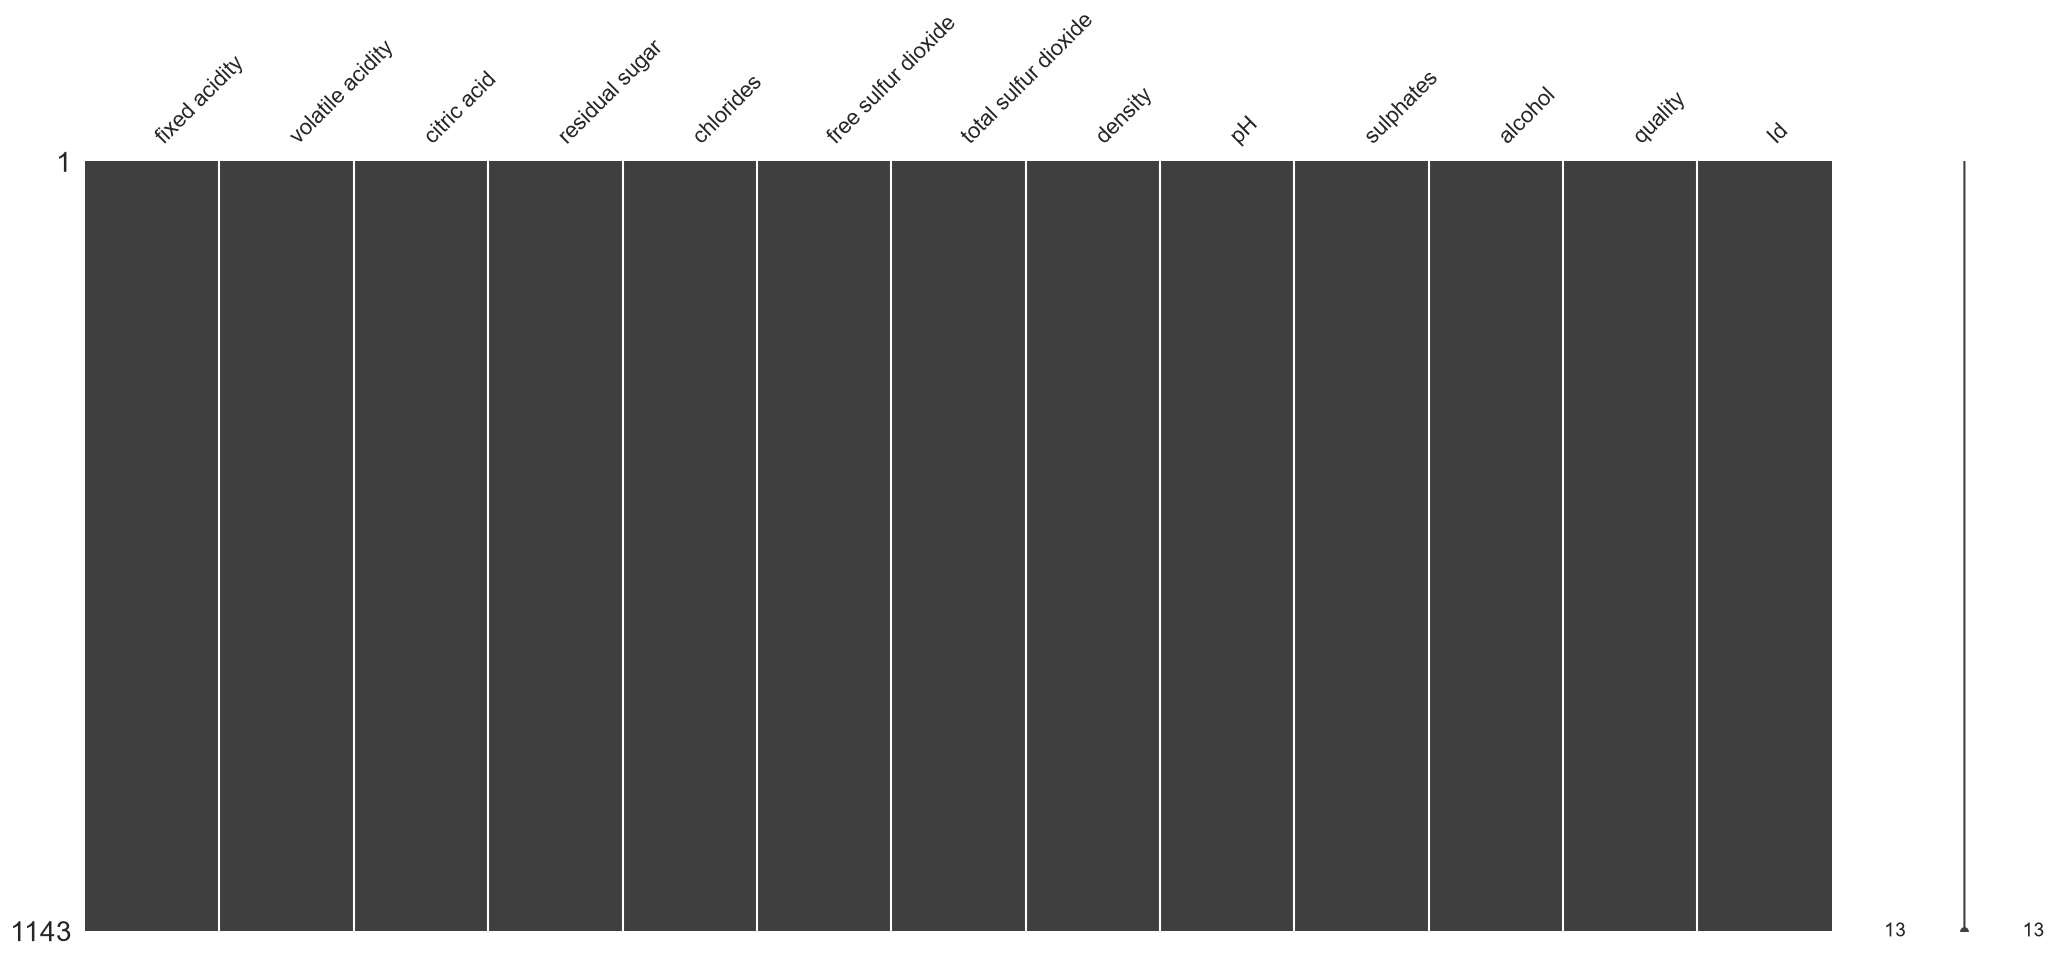

In [13]:
msno.matrix(df)

**Nota:** Não foram identificados valores ausentes ou nulos na base de dados analisada, mas existem valores Zerados que por hora não serão tratados, por poderem interferir na construção do modelo e acertividade das predições

#### Verificação de Valores Duplicados na base

In [14]:
duplicate_values = df.duplicated().sum()
print(f"Quantidade de valores duplicados: {duplicate_values}")

Quantidade de valores duplicados: 0


**Nota:** Reforçando a análise que não existem valores duplicados na base

#### Verificação de Valores Negativos na Base

In [15]:
valores_negativos = (df < 0).sum()
print(valores_negativos)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


**Nota**: Verificado que não existem valore negativos na base de dados, que poderia interferir na correta modelagem

#### Análise Estatística Descritiva da Base

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0000,8.3111,1.7476,4.6000,7.1000,7.9000,9.1000,15.9000
volatile acidity,1143.0000,0.5313,0.1796,0.1200,0.3925,0.5200,0.6400,1.5800
citric acid,1143.0000,0.2684,0.1967,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,1143.0000,2.5322,1.3559,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1143.0000,0.0869,0.0473,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1143.0000,15.6155,10.2505,1.0000,7.0000,13.0000,21.0000,68.0000
total sulfur dioxide,1143.0000,45.9147,32.7821,6.0000,21.0000,37.0000,61.0000,289.0000
density,1143.0000,0.9967,0.0019,0.9901,0.9956,0.9967,0.9978,1.0037
pH,1143.0000,3.3110,0.1567,2.7400,3.2050,3.3100,3.4000,4.0100
sulphates,1143.0000,0.6577,0.1704,0.3300,0.5500,0.6200,0.7300,2.0000


**Nota:** Podemos notar, dentre outras coisas, que a qualidade minima e máxima dada pelos especialistas nesta base estão entre 3 e 8 e que a média das notas gira em torno de 5.65, com desvio padrão de 0.8. O desvio padrão parece indicar que a qualidade dos vinhos é pouco dispersa ao redor da média (5.66). A base tem variáveis com escalas muito diferentes. StandardScaler?

#### Avaliando a Distribuição das Variáveis e Outliers

##### Distribuição de ``Quality``

Distribuição da Variável `quality` na base de dados: 


quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

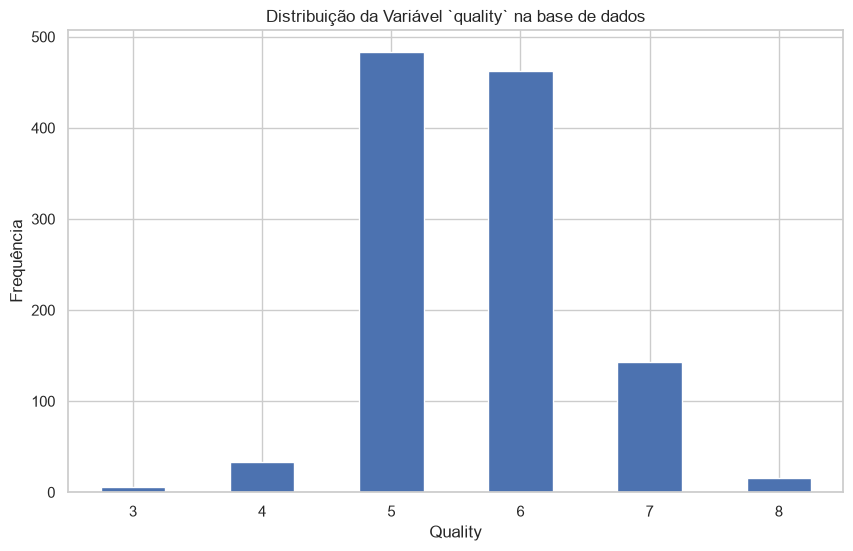

In [17]:
quality_counts = df["quality"].value_counts().sort_index()
print("Distribuição da Variável `quality` na base de dados: ")
display(quality_counts)

ax = quality_counts.plot(kind="bar")
ax.set_title("Distribuição da Variável `quality` na base de dados")
ax.set_xlabel("Quality")
ax.set_ylabel("Frequência")
plt.xticks(rotation=0)
plt.show()

**Nota:** Pode-se notar que a maior parte dos vinhos estão na faixas intermediárias de qualidade. A distribuição original das notas mostra que existe um comportamento concentrado em notas 5 (483 vinhos) e 6 (462 vinhos). Vinhos com qualidade alta e vinhos com baixa qualidade respondem por uma porcentagem muito baixa da base.

**Desafio aqui identificado:** Apoiar a identificação antecipada dos vinhos com maior potencial, e não apenas em classificar corretamente a massa de vinhos médios. A base reforça que o desafio é encontrar sinais confiáveis em um grupo pequeno, porém relevante para decisões de qualidade, posicionamento e priorização de lotes.

##### Analisando a distribuição de cada Variável Característica e seus Outliers

In [18]:
def detalhe_ouliers ():
    """
    Função para detalhar os outliers da base de dados.
    Identificando outliers usando o método do IQR
    """
    features = df.drop(columns=['quality', 'Id'], errors='ignore').select_dtypes(include='number').columns

    features = df.drop(columns=['quality', 'Id'], errors='ignore').select_dtypes(include='number').columns

    resumo_outlier = []

    for col in features:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        resumo_outlier.append({
            'variavel': col,
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'limite_inferior': lower_bound,
            'limite_superior': upper_bound,
            'qtd_outliers': outliers.shape[0],
            'pct_outliers': outliers.shape[0] / df.shape[0] * 100
        })

    outlier_summary_df = pd.DataFrame(resumo_outlier)

    outlier_summary_df.sort_values(
        by='qtd_outliers',
        ascending=False,
        inplace=True
    )
    return outlier_summary_df


In [19]:
def detalhe_media_variavel(col):
    """
    Função que calcula as médias e diferença das médias por classe:

    Parâmetros:
    Col: feature que será calculada as médias e diferenças

    Retorno: none 

    """
    
    # Classe Baixa/Média (quality < 7)
    media_baixa_media = df[df['quality'] < 7][col].mean()

    # Classe Alta (quality >= 7)
    media_alta = df[df['quality'] >= 7][col].mean()

    # Diferença
    diferenca = media_alta - media_baixa_media

    print(f"Variável analisada: {col}")
    print(f"Média Baixa/Média: {media_baixa_media:.3f}")
    print(f"Média Alta: {media_alta:.3f}")
    print(f"Diferença: {diferenca:.3f}")

Resumo de outliers por variável:


,variavel,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers,pct_outliers
3,residual sugar,1.900,2.600,0.700,0.850,3.650,110,9.62%
4,chlorides,0.070,0.090,0.020,0.040,0.120,77,6.74%
0,fixed acidity,7.100,9.100,2.000,4.100,12.100,44,3.85%
9,sulphates,0.550,0.730,0.180,0.280,1.000,43,3.76%
6,total sulfur dioxide,21.000,61.000,40.000,-39.000,121.000,40,3.50%
7,density,0.996,0.998,0.002,0.992,1.001,36,3.15%
8,pH,3.205,3.400,0.195,2.913,3.692,20,1.75%
5,free sulfur dioxide,7.000,21.000,14.000,-14.000,42.000,18,1.57%
1,volatile acidity,0.393,0.640,0.247,0.021,1.011,14,1.22%
10,alcohol,9.500,11.100,1.600,7.100,13.500,12,1.05%


Análise detalhada de outliers por variável:


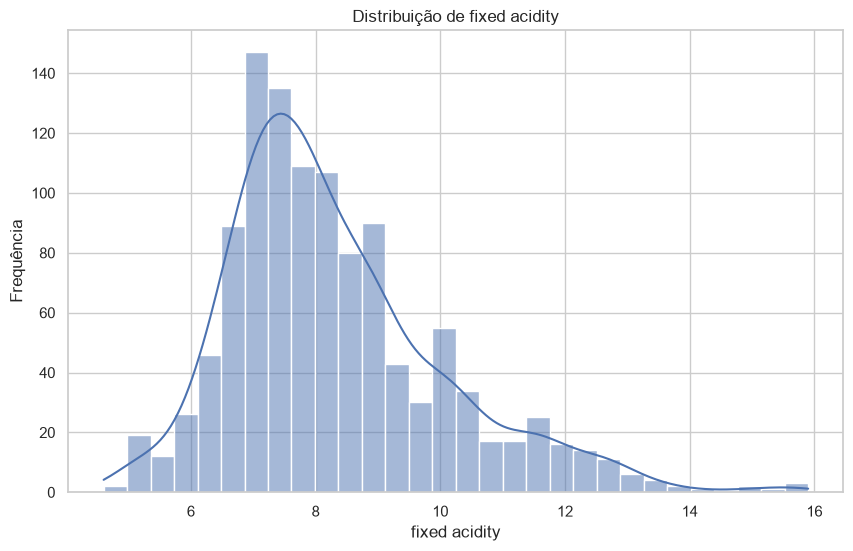

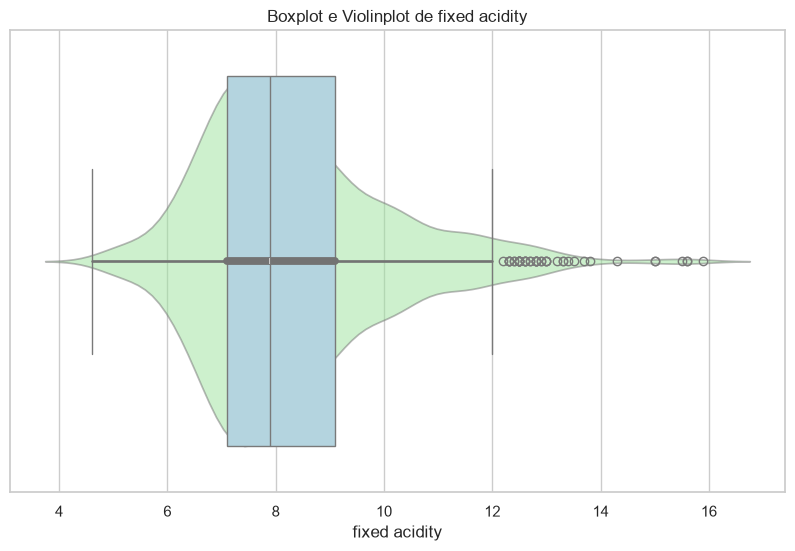

Outliers de fixed acidity: 44 registros


,Id,fixed acidity,quality
279,402,12.2000,6
306,435,12.3000,5
304,433,12.3000,5
416,581,12.3000,5
415,580,12.3000,5
425,596,12.4000,6
392,548,12.4000,6
284,409,12.5000,4
367,516,12.5000,6
313,446,12.5000,5



Resumo das médias por classe:
Variável analisada: fixed acidity
Média Baixa/Média: 8.225
Média Alta: 8.847
Diferença: 0.622


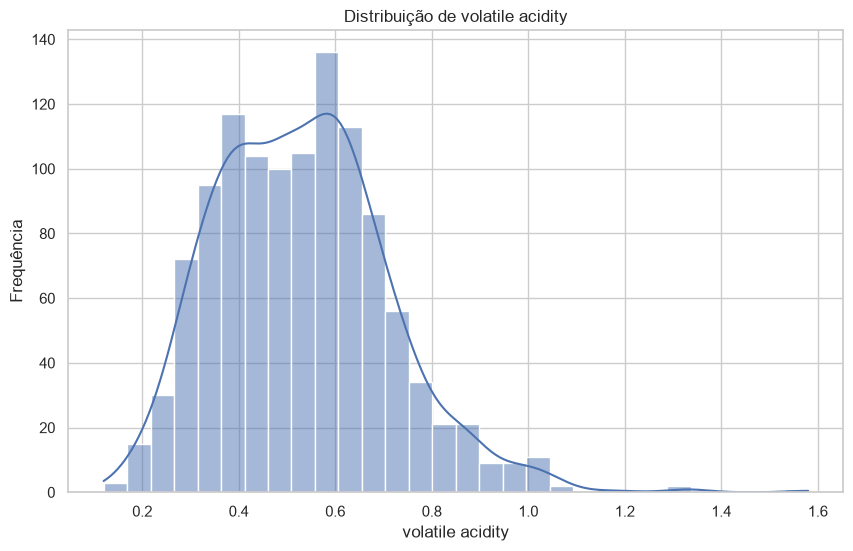

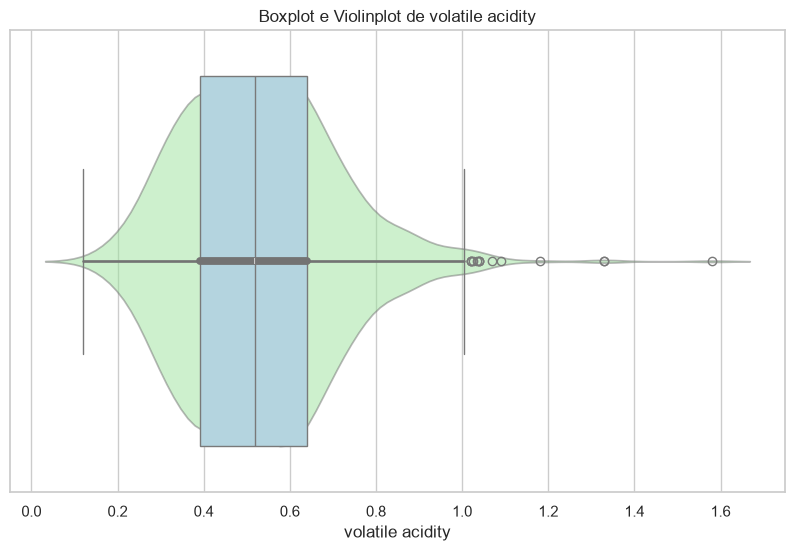

Outliers de volatile acidity: 14 registros


,Id,volatile acidity,quality
66,94,1.0200,4
497,700,1.0200,6
891,1261,1.0200,4
506,710,1.0250,5
502,705,1.0350,5
1044,1467,1.0400,4
92,134,1.0400,6
396,553,1.0400,5
83,120,1.0700,5
142,199,1.0900,4



Resumo das médias por classe:
Variável analisada: volatile acidity
Média Baixa/Média: 0.553
Média Alta: 0.395
Diferença: -0.158


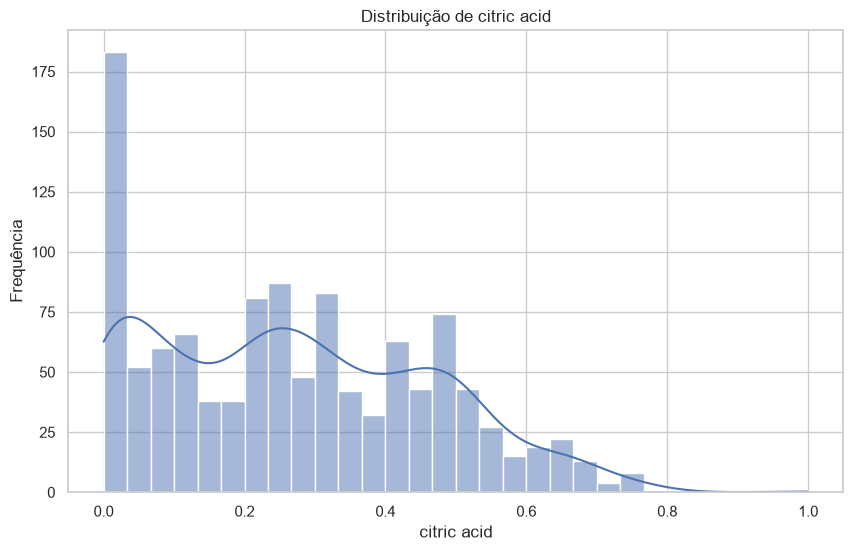

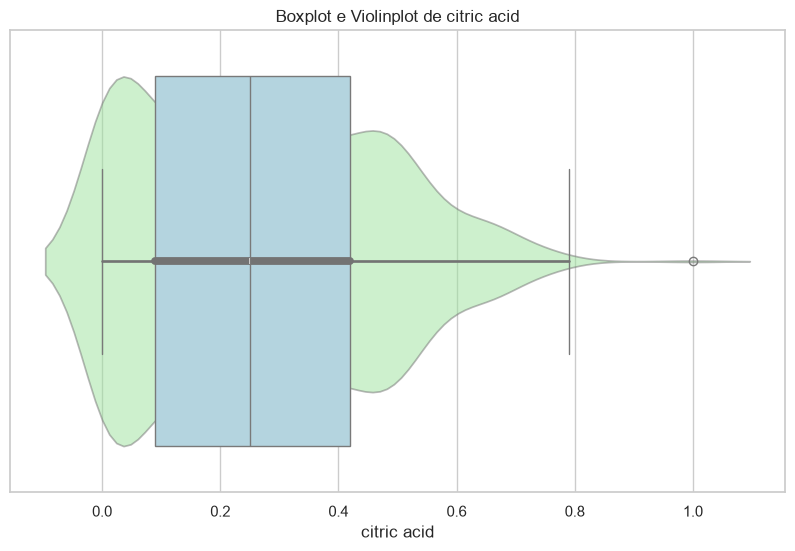

Outliers de citric acid: 1 registros


,Id,citric acid,quality
103,151,1.0000,4



Resumo das médias por classe:
Variável analisada: citric acid
Média Baixa/Média: 0.249
Média Alta: 0.391
Diferença: 0.143


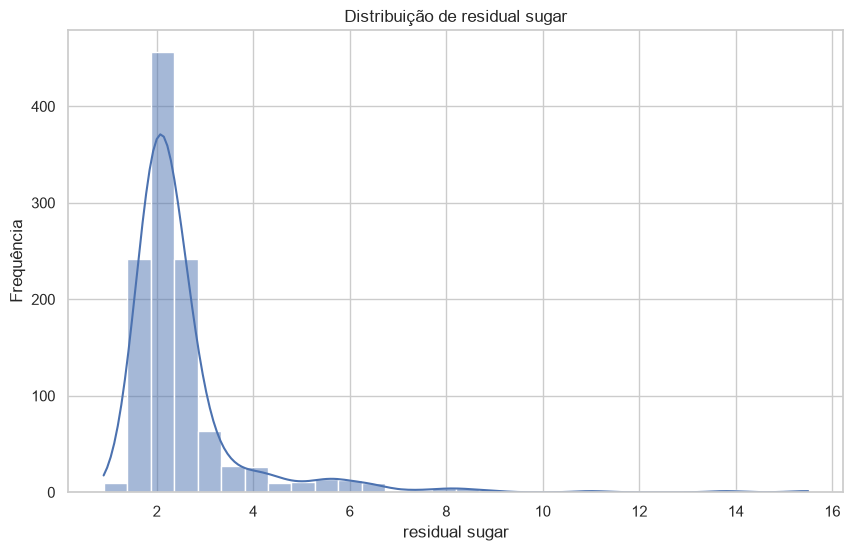

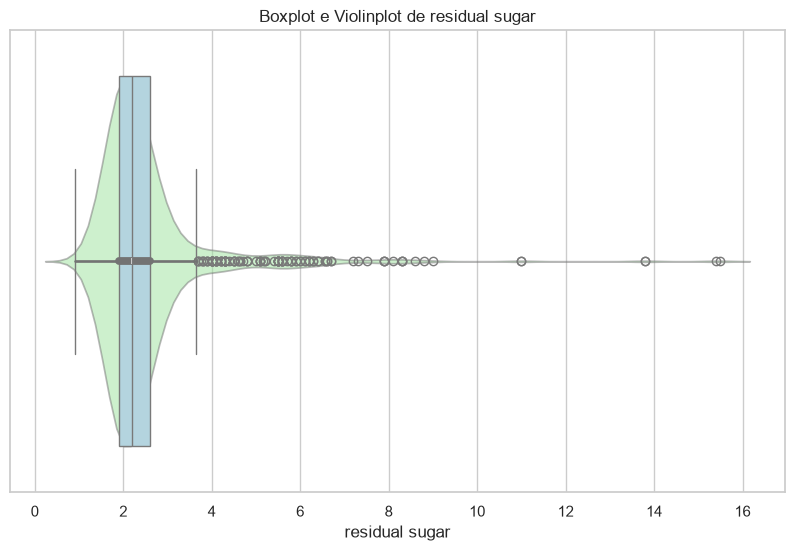

Outliers de residual sugar: 110 registros


,Id,residual sugar,quality
311,442,3.7000,7
804,1138,3.7000,5
1106,1552,3.7000,6
1048,1471,3.7500,5
944,1331,3.8000,5
...,...,...,...
231,325,11.0000,6
1051,1474,13.8000,5
1053,1476,13.8000,5
1022,1434,15.4000,6



Resumo das médias por classe:
Variável analisada: residual sugar
Média Baixa/Média: 2.497
Média Alta: 2.748
Diferença: 0.251


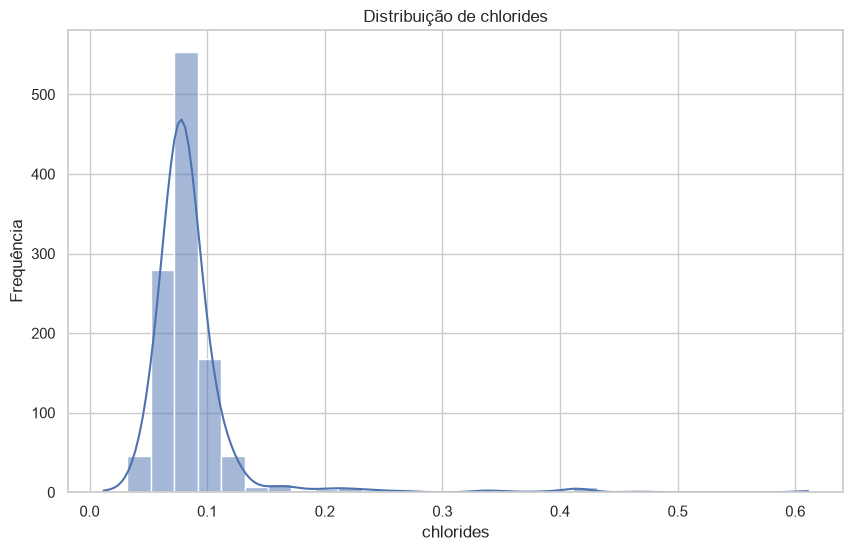

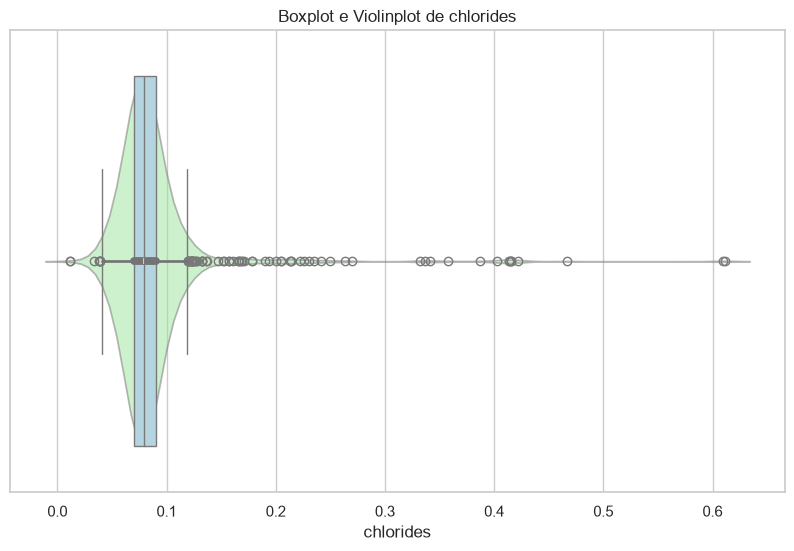

Outliers de chlorides: 77 registros


,Id,chlorides,quality
598,837,0.0120,7
597,836,0.0120,7
493,695,0.0340,6
574,797,0.0380,7
1123,1571,0.0380,6
...,...,...,...
973,1370,0.4150,5
490,692,0.4220,5
75,106,0.4670,5
103,151,0.6100,4



Resumo das médias por classe:
Variável analisada: chlorides
Média Baixa/Média: 0.089
Média Alta: 0.075
Diferença: -0.014


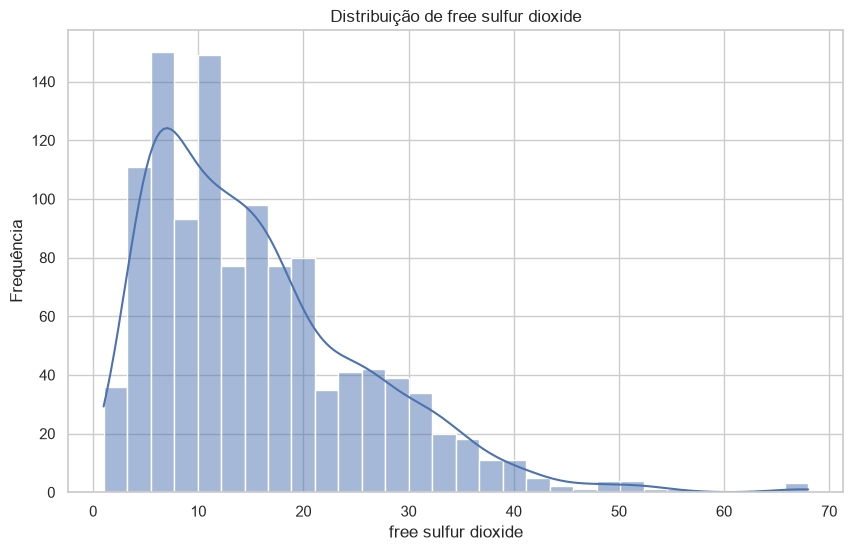

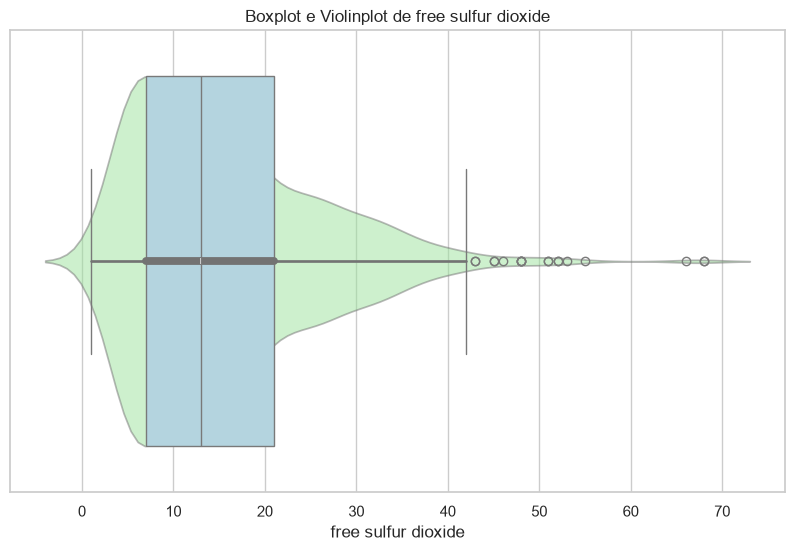

Outliers de free sulfur dioxide: 18 registros


,Id,free sulfur dioxide,quality
351,497,43.0000,5
887,1256,43.0000,5
820,1156,45.0000,7
480,678,45.0000,5
450,634,46.0000,5
831,1175,48.0000,6
871,1231,48.0000,5
1051,1474,48.0000,5
1053,1476,48.0000,5
690,982,51.0000,6



Resumo das médias por classe:
Variável analisada: free sulfur dioxide
Média Baixa/Média: 15.846
Média Alta: 14.189
Diferença: -1.657


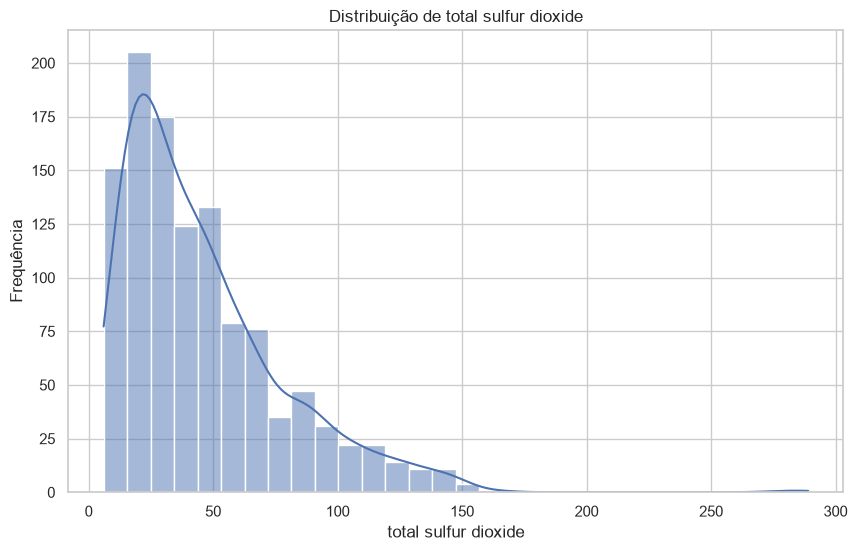

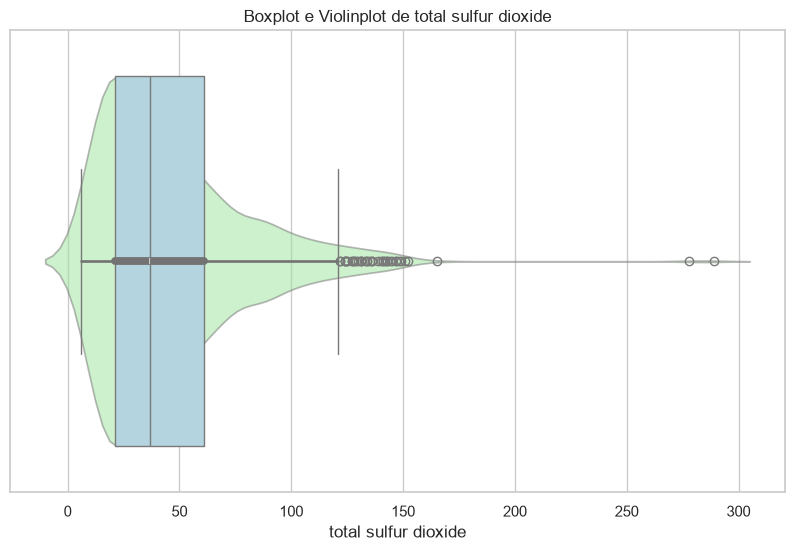

Outliers de total sulfur dioxide: 40 registros


,Id,total sulfur dioxide,quality
288,414,122.0000,5
491,693,122.0000,5
278,400,124.0000,5
275,396,124.0000,5
291,417,124.0000,5
492,694,125.0000,5
61,88,125.0000,5
136,190,127.0000,5
514,723,127.0000,5
106,155,128.0000,5



Resumo das médias por classe:
Variável analisada: total sulfur dioxide
Média Baixa/Média: 47.408
Média Alta: 36.673
Diferença: -10.735


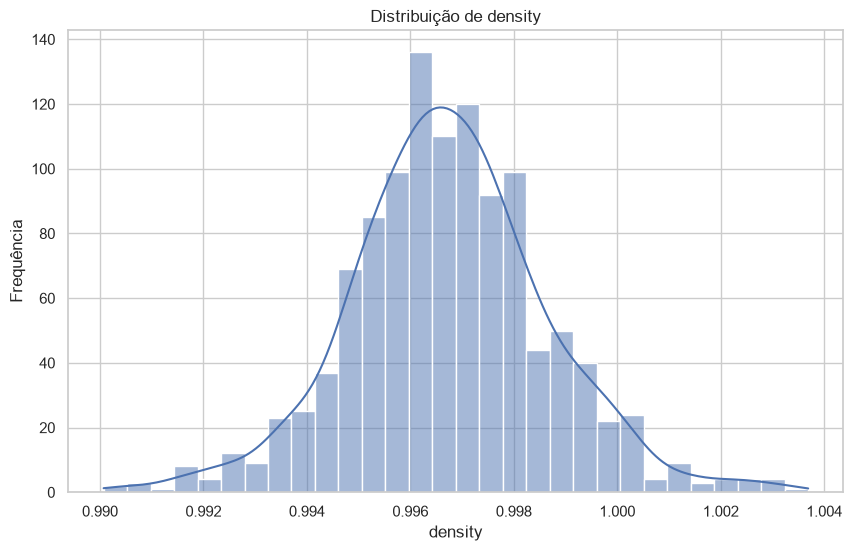

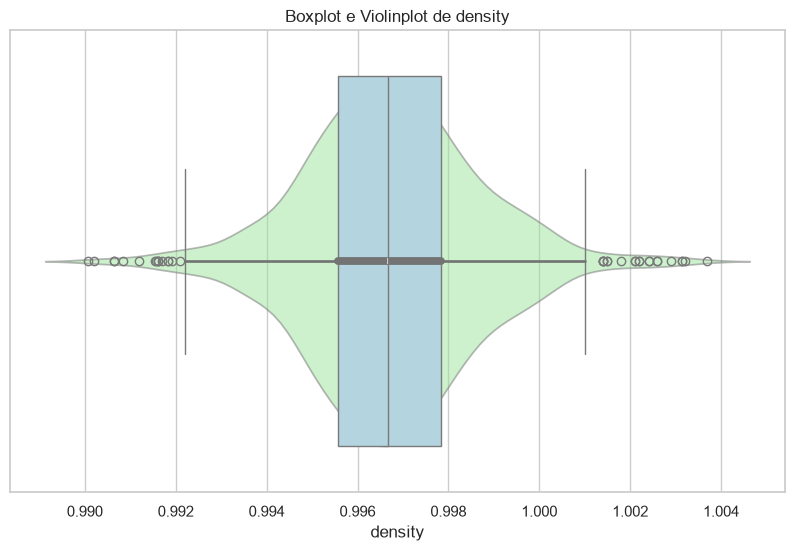

Outliers de density: 36 registros


,Id,density,quality
714,1018,0.9901,6
787,1114,0.9902,6
598,837,0.9906,7
597,836,0.9906,7
898,1270,0.9908,6
249,354,0.9912,6
589,821,0.9915,7
868,1228,0.9916,7
98,144,0.9916,6
96,142,0.9916,6



Resumo das médias por classe:
Variável analisada: density
Média Baixa/Média: 0.997
Média Alta: 0.996
Diferença: -0.001


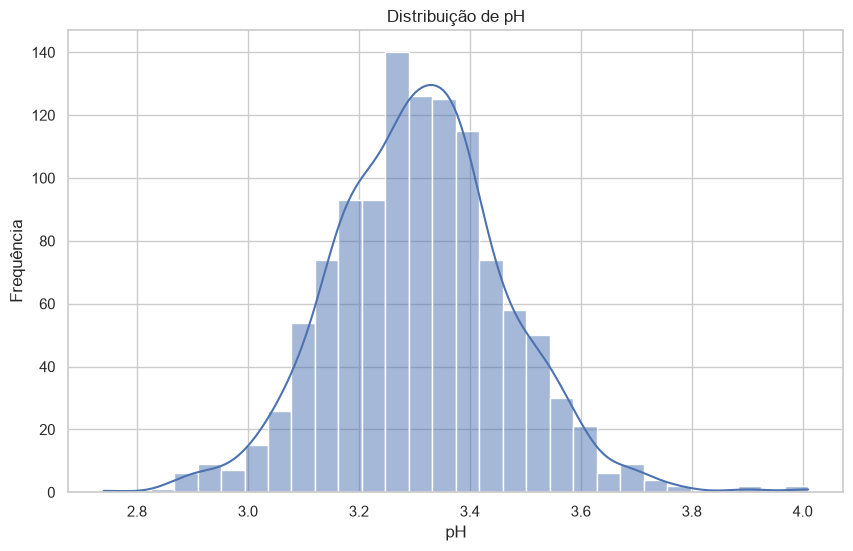

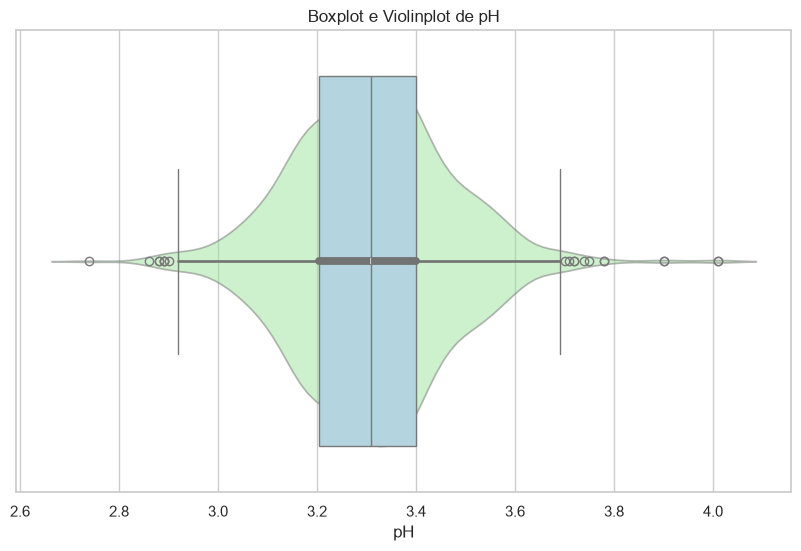

Outliers de pH: 20 registros


,Id,pH,quality
103,151,2.7400,4
388,544,2.8600,6
310,440,2.8800,8
1047,1470,2.8800,5
714,1018,2.8900,6
466,656,2.8900,5
461,650,2.8900,5
934,1319,2.9000,6
898,1270,3.7000,6
589,821,3.7100,7



Resumo das médias por classe:
Variável analisada: pH
Média Baixa/Média: 3.316
Média Alta: 3.282
Diferença: -0.033


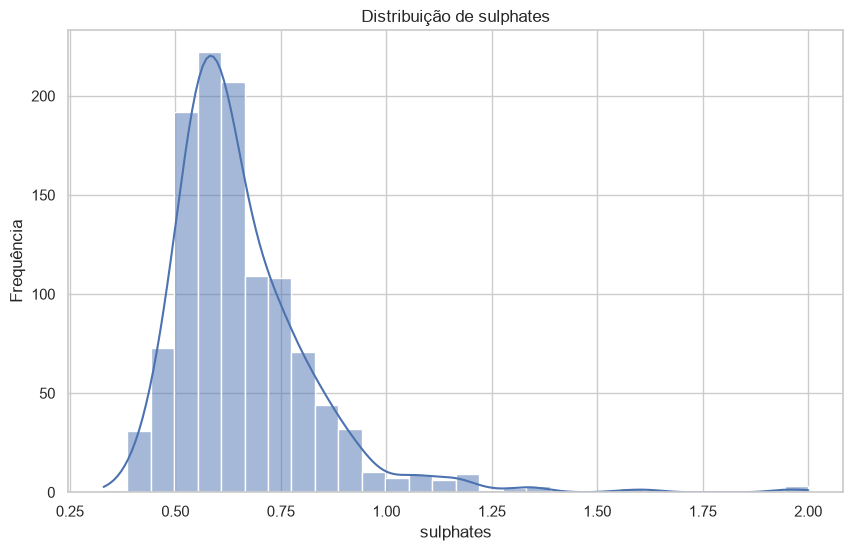

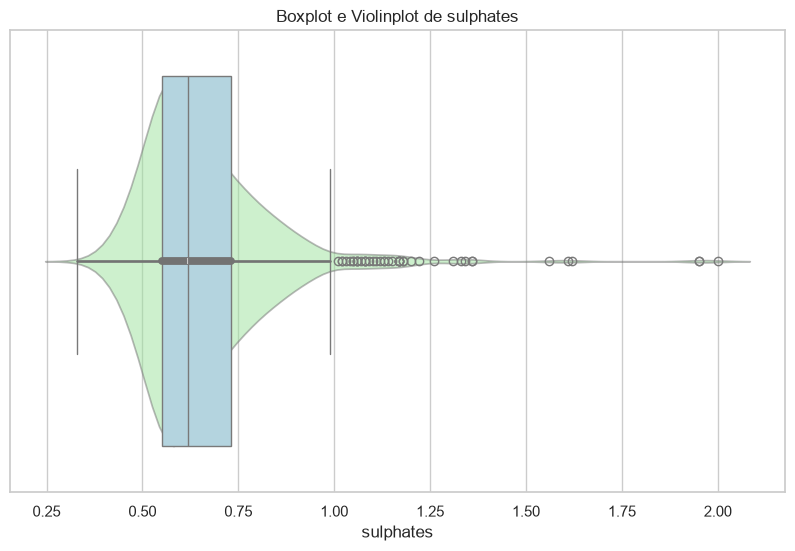

Outliers de sulphates: 43 registros


,Id,sulphates,quality
1000,1408,1.0100,7
129,181,1.0200,5
359,506,1.0200,7
974,1371,1.0300,6
264,372,1.0400,6
488,689,1.0500,5
357,504,1.0500,7
341,483,1.0600,5
538,754,1.0600,6
337,477,1.0600,6



Resumo das médias por classe:
Variável analisada: sulphates
Média Baixa/Média: 0.643
Média Alta: 0.746
Diferença: 0.102


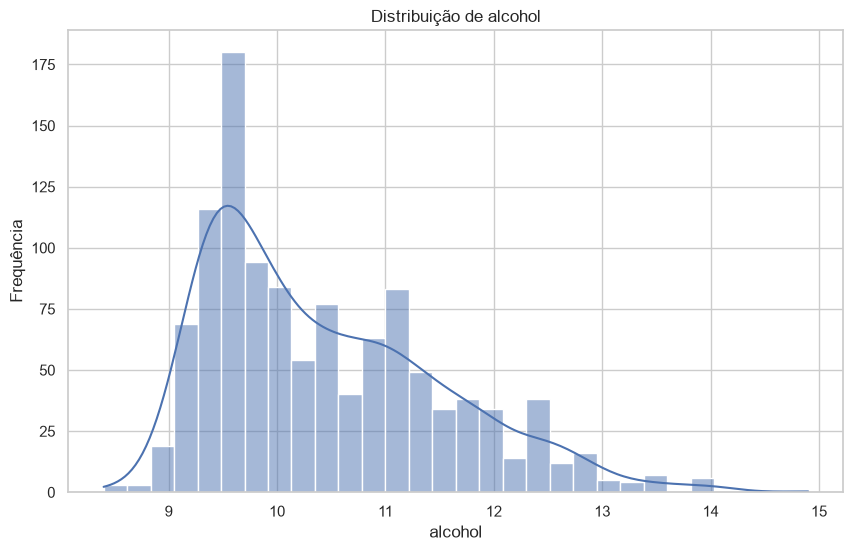

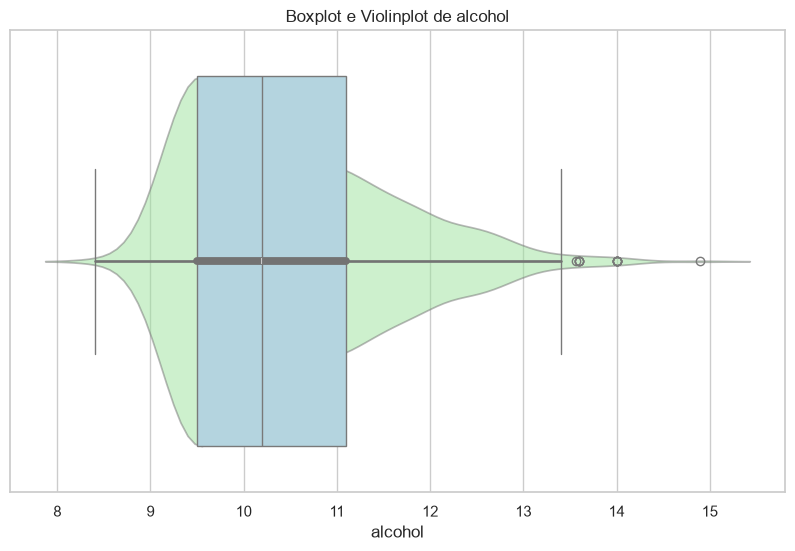

Outliers de alcohol: 12 registros


,Id,alcohol,quality
1052,1475,13.5667,7
787,1114,13.6000,6
868,1228,13.6000,7
799,1132,13.6000,7
1054,1477,13.6000,7
419,588,14.0000,8
96,142,14.0000,6
98,144,14.0000,6
329,467,14.0000,6
589,821,14.0000,7



Resumo das médias por classe:
Variável analisada: alcohol
Média Baixa/Média: 10.267
Média Alta: 11.528
Diferença: 1.262


In [20]:
# Calcula e imprime o resumo geral dos outliers por variável e gráficos de Boxplot e Violin por variável além do detalhe dos outliers por variável

resumo_outlier = detalhe_ouliers()

print("Resumo de outliers por variável:")
display(
    resumo_outlier.sort_values(by="qtd_outliers", ascending=False).style.format({
        "q1": "{:.3f}",
        "q3": "{:.3f}",
        "iqr": "{:.3f}",
        "limite_inferior": "{:.3f}",
        "limite_superior": "{:.3f}",
        "pct_outliers": "{:.2f}%"
    })
)

num_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ["quality", "Id"]
]

print("Análise detalhada de outliers por variável:")

for col in num_cols:
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

    sns.boxplot(x=df[col], color="lightblue")
    sns.violinplot(x=df[col], color="lightgreen", alpha=0.5)
    plt.title(f"Boxplot e Violinplot de {col}")
    plt.xlabel(col)
    plt.show()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers_col = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"Outliers de {col}: {outliers_col.shape[0]} registros")
    if outliers_col.empty:
        print("Nenhum outlier encontrado para esta variável.")
    else:
        colunas_exibir = [c for c in ["Id", col, "quality"] if c in outliers_col.columns]
        display(outliers_col[colunas_exibir].sort_values(by=col))

    print("\nResumo das médias por classe:")

    detalhe_media_variavel(col)

**Nota:** Para complementar a análise visual dos boxplots e violin, foi calculada e detalhada a quantidade de outliers por variável, usando o método do intervalo interquartil (IQR). Valores abaixo de Q1 - 1,5 × IQR ou acima de Q3 + 1,5 × IQR são classificados como outliers.

A presença de outliers não implica remoção automática. No contexto deste projeto, os valores extremos representam características físico-químicas reais de determinados vinhos e, portanto, devem ser avaliados com cautela. Como o objetivo é classificação, esses pontos podem conter informação útil para diferenciar vinhos de alta qualidade.

Os outliers da base se concentram principalmente em ``residual sugar`` e ``chlorides``. Isso indica assimetria em algumas variáveis físico-químicas, mas não significa necessariamente erro de medição. No contexto de vinhos, valores extremos podem refletir perfis reais de produção, fermentação, composição e estilo do vinho.

Algumas variáveis têm caudas longas (chlorides, sulphates, residual sugar, sulfur dioxide) e variáveis como alcohol, volatile acidity, density e sulphates parecem tender a ser mais preditivas.

***PONTO IDENTIFICADO:*** Os outliers não serão removidos automaticamente. Melhor mantê-los e tratar o impacto por meio da modelagem, pois evita descartar informação que pode ser útil para distinguir vinhos de alta qualidade.

***ANÁLISE DA DISTRIBUIÇÃO:*** Nos boxplots, vinhos de alta qualidade apresentam uma distribuição mais elevada em ``alcohol`` e ``sulphates``, enquanto tendem a apresentar menor ``volatile acidity``. Essas diferenças são relevantes porque aparecem tanto na análise visual quanto nas correlações numéricas.



#### Distribuição das variáveis em uma só Figura

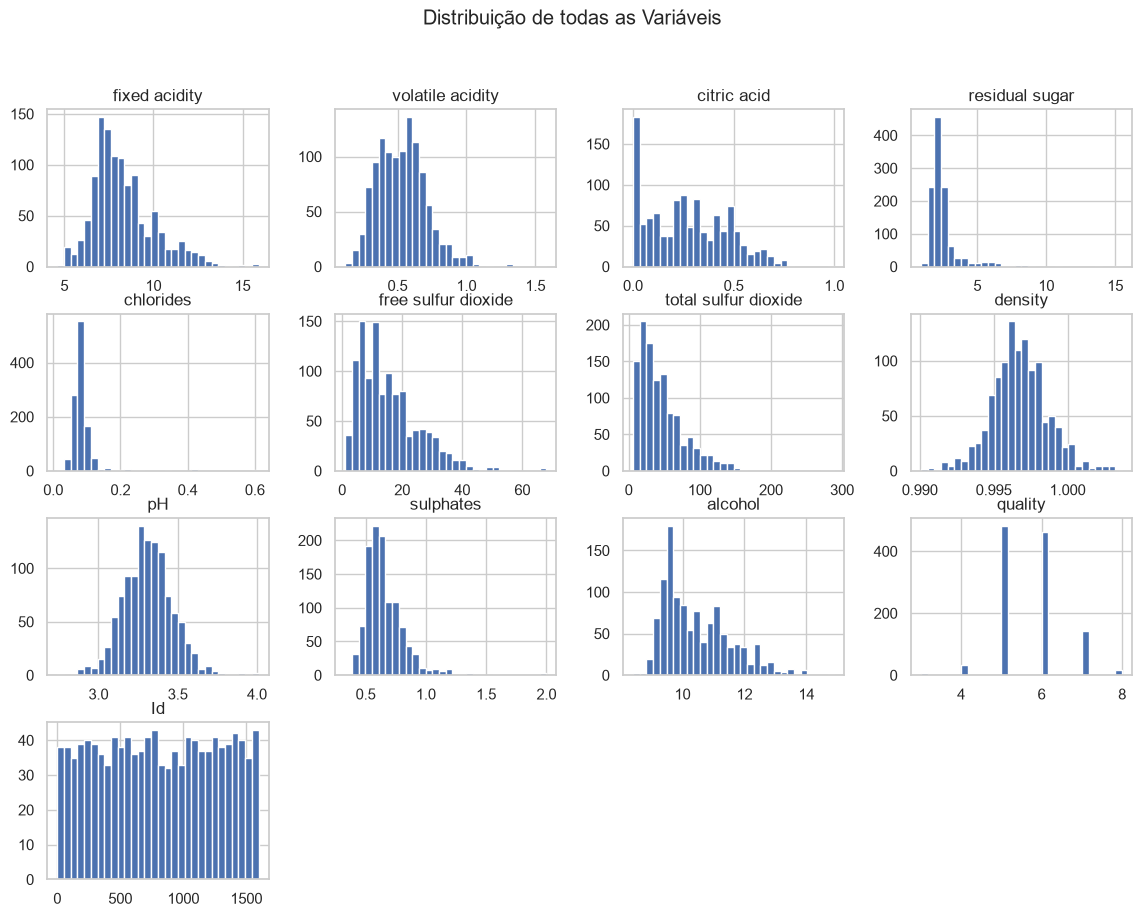

In [21]:
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribuição de todas as Variáveis")
plt.show()

#### Correlacão das Variáveis com `quality`

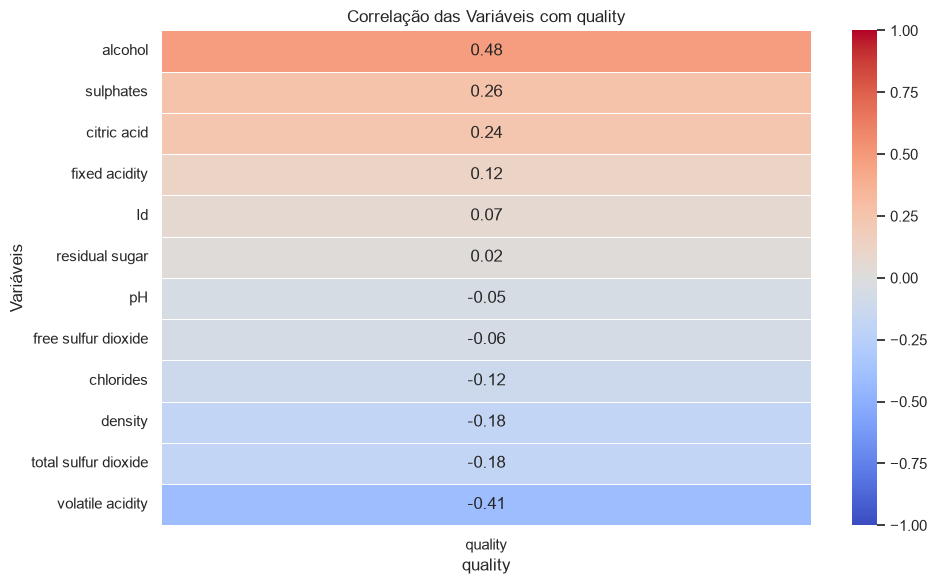

In [22]:
corr_quality = (
    df.corr(numeric_only=True)[["quality"]]
    .drop(index="quality")
    .sort_values(by="quality", ascending=False)
    .round(2)
)

fig, ax = plt.subplots()
sns.heatmap(
    data=corr_quality,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=ax
)
ax.set_title("Correlação das Variáveis com quality")
ax.set_xlabel("quality")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

C:\Users\bruno.oliveira\AppData\Local\Temp\ipykernel_24368\4251616103.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_sem_quality.values, y=corr_sem_quality.index, palette=cores)


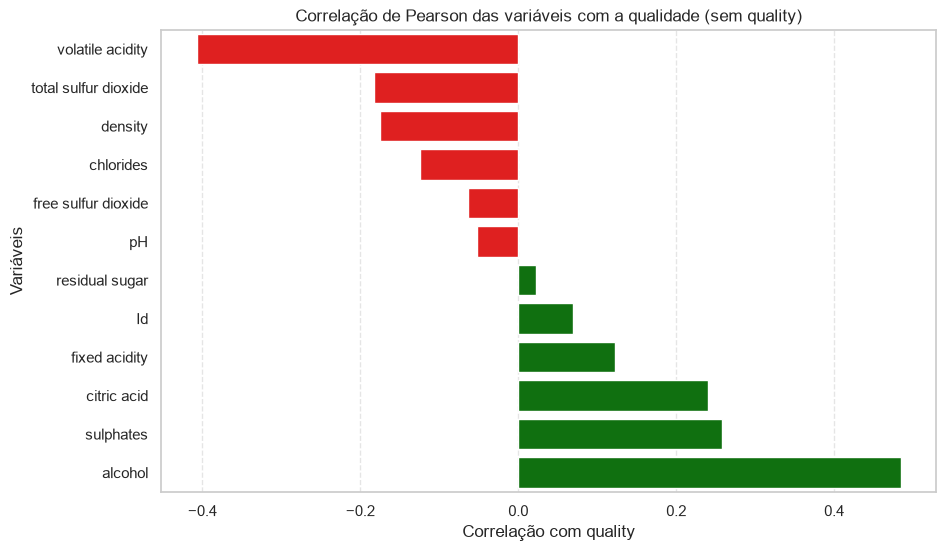

In [23]:
# Calcula a correlação de Pearson de todas as variáveis
corr = df.corr(method='pearson')

# Remover a variável 'quality'
corr_sem_quality = corr['quality'].drop('quality').sort_values()

# Verde para correlação positiva, vermelho para negativa
cores = ['green' if c > 0 else 'red' for c in corr_sem_quality]

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_sem_quality.values, y=corr_sem_quality.index, palette=cores)

plt.title("Correlação de Pearson das variáveis com a qualidade (sem quality)")
plt.xlabel("Correlação com quality")
plt.ylabel("Variáveis")
plt.grid(axis='x', linestyle='--', alpha=0.5)


#### Distribuição das principais variáveis por classe de qualidade

C:\Users\bruno.oliveira\AppData\Local\Temp\ipykernel_24368\1998579916.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bruno.oliveira\AppData\Local\Temp\ipykernel_24368\1998579916.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bruno.oliveira\AppData\Local\Temp\ipykernel_24368\1998579916.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bruno.oliveira\AppData\Local\Temp\ipykernel_24368\1998579916.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

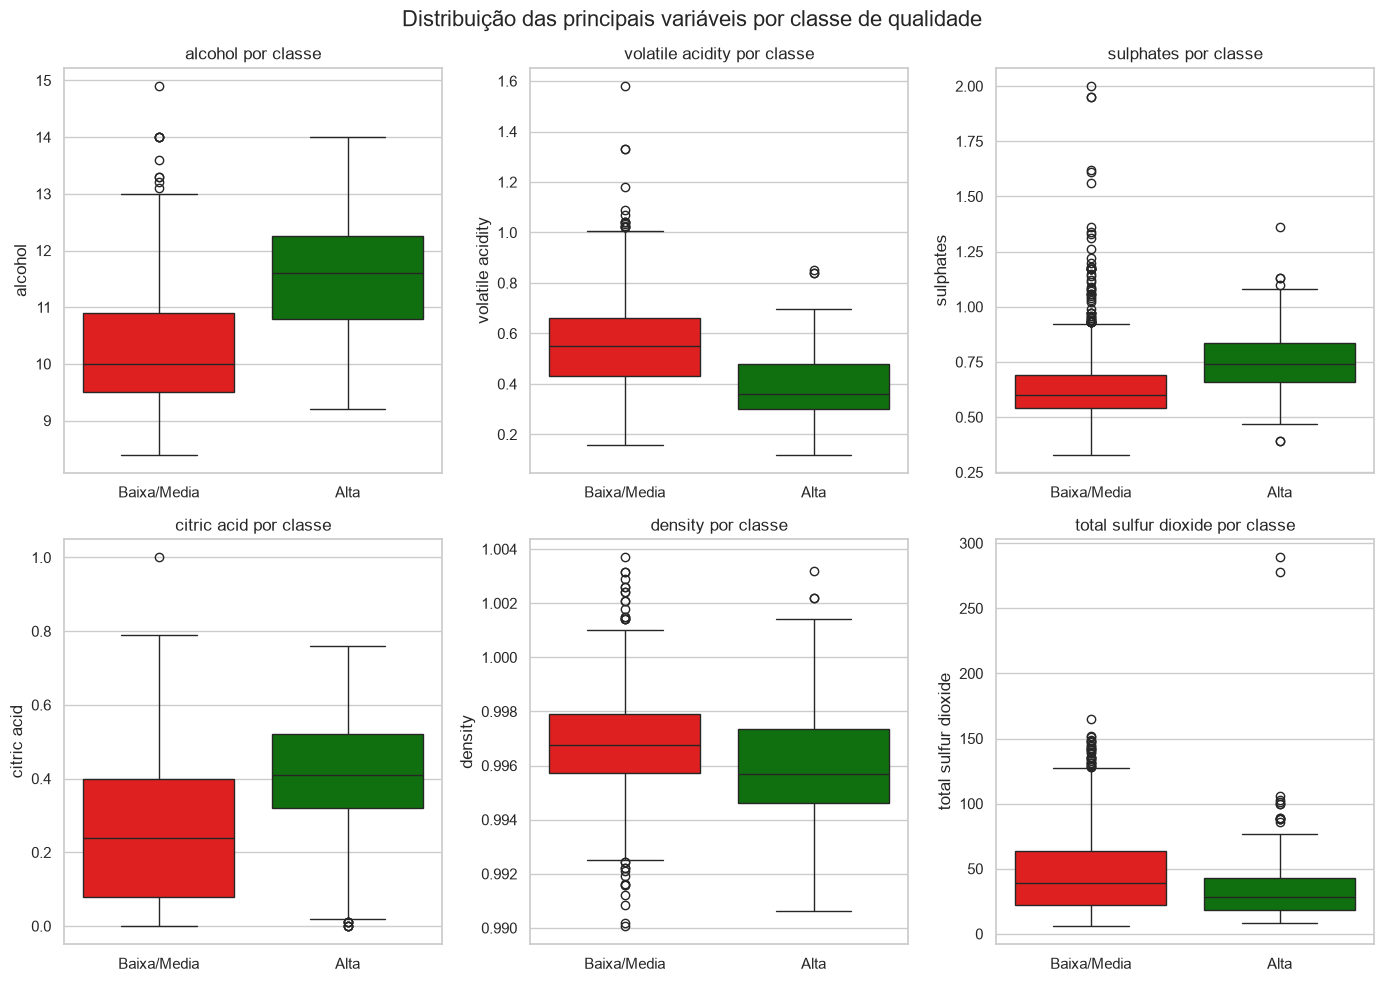

In [24]:
df['classe'] = df['quality'].apply(lambda x: 'Alta' if x >= 7 else 'Baixa/Media')

variaveis = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'density',
    'total sulfur dioxide'
]

plt.figure(figsize=(14, 10))

for i, var in enumerate(variaveis, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        data=df,
        x='classe',
        y=var,
        palette={'Baixa/Media': 'red', 'Alta': 'green'}
    )
    plt.title(f"{var} por classe")
    plt.xlabel("")
    plt.ylabel(var)

plt.suptitle("Distribuição das principais variáveis por classe de qualidade", fontsize=16)
plt.tight_layout()
plt.show()

Deletando a Coluna auxiliar Classe criada para plotar o gráfico acima

In [25]:
if "classe" in df.columns:
    df.drop(columns=["classe"], inplace=True)
#Validando se realmente excluiu
df.head(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,0


**Nota:** A comparação visual entre as classes nos mostra que, nos boxplots, vinhos de alta qualidade apresentam uma distribuição mais elevada em ``alcohol`` e ``sulphates``, enquanto tendem a apresentar menor ``volatile acidity``.

#### Separando em classes e avaliando a quantidade de vinhos por classe (0 - Baixa/Média e 1 - Alta): 

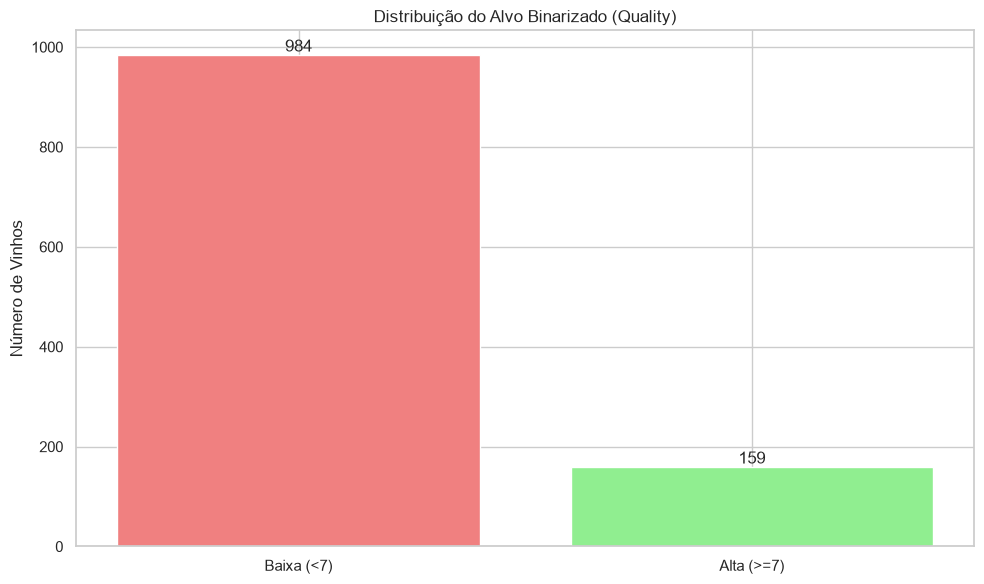

In [26]:
cla = {
    "Baixa (<7)": (df["quality"] < 7).sum(),
    "Alta (>=7)": (df["quality"] >= 7).sum()
}


plt.figure()
bars = plt.bar(cla.keys(), cla.values(), color=["lightcoral", "lightgreen"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.title("Distribuição do Alvo Binarizado (Quality)")
plt.ylabel("Número de Vinhos")
plt.tight_layout()
plt.show()



#### Avaliando se existem registros idênticos

In [44]:
df_tmp = df.drop(columns=[c for c in ["Id"] if c in df.columns]).copy()

# Verificando idênticos por ID
n_dup = df_tmp.duplicated(keep=False)

# Exibir apenas os registros idênticos
dups = df[n_dup]

print(dups)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4000            0.7000       0.0000          1.9000     0.0760   
4            7.4000            0.7000       0.0000          1.9000     0.0760   
45           7.2000            0.7250       0.0500          4.6500     0.0860   
46           7.2000            0.7250       0.0500          4.6500     0.0860   
59           8.6000            0.4900       0.2800          1.9000     0.1100   
...             ...               ...          ...             ...        ...   
1113         7.8000            0.6000       0.2600          2.0000     0.0800   
1114         7.8000            0.6000       0.2600          2.0000     0.0800   
1115         7.2000            0.6950       0.1300          2.0000     0.0760   
1116         7.2000            0.6950       0.1300          2.0000     0.0760   
1119         7.2000            0.6950       0.1300          2.0000     0.0760   

      free sulfur dioxide  

**Nota:** Encontrado 239 registros idênticos na base.

In [ ]:
#Verificando registros identicos com TRUE ou FALSE
n_dup = df_tmp.duplicated(keep=False)
n_dup

0        True
1       False
2       False
3       False
4        True
        ...  
1138    False
1139    False
1140    False
1141    False
1142    False
Length: 1143, dtype: bool

In [45]:
qtd_dup = df_tmp.duplicated().sum()
print(f"Quantidade de registros idênticos: ", qtd_dup)

Quantidade de registros idênticos:  125


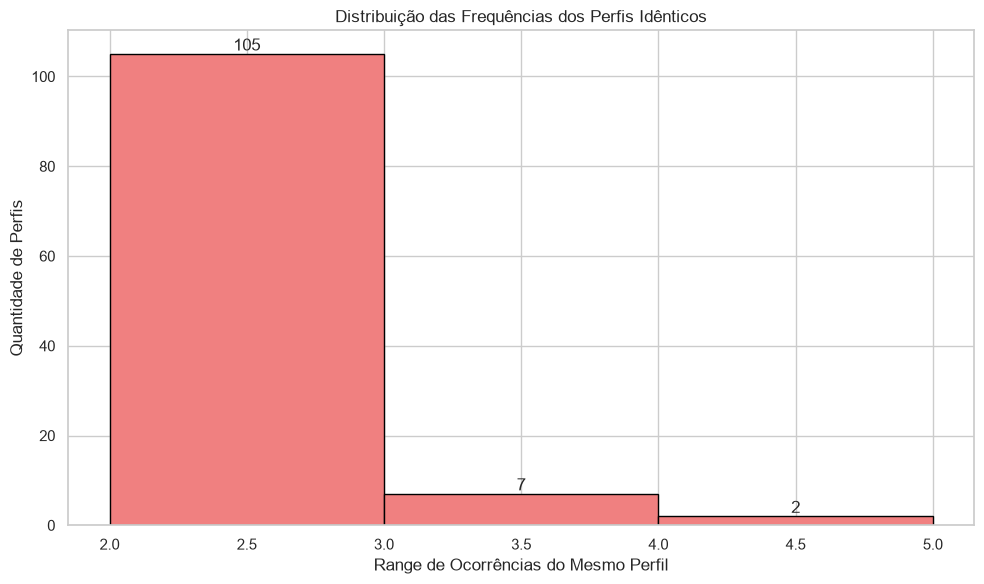

In [46]:
freq = df_tmp.value_counts().reset_index(name="count")

dups_freq = freq[freq["count"] > 1]

plt.figure()
bars = plt.hist(
    dups_freq["count"],
    bins=range(2, dups_freq["count"].max() + 2),
    color="lightcoral",
    edgecolor="black"
)

plt.title("Distribuição das Frequências dos Perfis Idênticos")
plt.xlabel("Range de Ocorrências do Mesmo Perfil")
plt.ylabel("Quantidade de Perfis")

for count, patch in zip(bars[0], bars[2]):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count,
        str(int(count)),
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()



**Nota:** Quantidade total de registros únicos idênticos por ID: 125. Ou seja, dos 239 registros idênticos por ID, 125 são únicos. Isso mostra que existem 125 linhas cujo perfil físico‑químico aparece mais de uma vez no dataset. Cada uma dessas linhas pertence a algum grupo idêntico:

- 105 regisrtos aparecem de 2 a 3 vezes, 7 de 3 a 4 vezes e 2 de 4 a 5 vezes - totalizando 239 registros, sendo 125 únicos

### Resumo dos Principais achados da Análise Exploratória (EDA)
#### Os detalhes da EDA podem ser lidos no relatório executivo (conforme descrição dos entregáveis no README.MD)

Síntese dos pontos que orientam o pré-processamento e a modelagem:

 - **Alvo desbalanceado.** Após binarizar `quality` (alta = nota ≥ 7), apenas
  **159 de 1.143 vinhos (~13,9%) são de alta qualidade**. A classe positiva é
  **rara**, o que torna a **acurácia isolada enganosa** e exige métricas como
  **ROC-AUC, recall e F1** da classe minoritária. Já identificado na EDA que será melhor
  utilizar o split estratificado para treinamento do medelo, pois além de termos que 
  descartar muitos dados dos vinhos de média/baixa ou duplicar dados de vinhos de alta qualidade
  para iqualar artificialmente a base de treino e teste a técnica de split estratificado permite 
  evitar o viés acidental ao garantir que a proporção entre vinhos de baixa/média e alta qualidade 
  seja preservada tanto no treino quanto no teste. Como a classe de alta qualidade é rara na base,
  o estratificado assegura que ela esteja representada de forma adequada, sem criar um equilíbrio 
  artificial que não existe nos dados reais.
- **Qualidade dos dados.** Não há **valores ausentes**. Sem a coluna `Id`,
  existem **125 registros com perfil físico-químico idêntico**; eles são
  **removidos antes do split** para evitar *data leakage* (o mesmo vinho - ou muito parecidos - aparecer
  em treino e teste), resultando em 1.018 amostras para modelagem.
- **Variáveis associadas à alta qualidade.** As maiores correlações com a nota
  são **álcool (+0,48)** e **acidez volátil (−0,41)**, seguidas de **sulfatos
  (+0,26)** e **ácido cítrico (+0,24)**. Ou seja: mais álcool, mais sulfatos e
  **menos** acidez volátil tendem a acompanhar vinhos melhor avaliados —
  coerente com o conhecimento enológico.
- **Outliers por variável (método IQR).** Concentram-se em **açúcar residual
  (~9,6%)** e **cloretos (~6,7%)**; as demais ficam abaixo de ~4%. Eles refletem
  a assimetria natural dessas medições.
- **Decisão sobre outliers: não remover automaticamente.** No domínio enológico,
  esses valores extremos costumam representar **perfis físico-químicos reais** e
  podem carregar sinal útil para distinguir vinhos de alta qualidade. Removê-los
  às cegas descartaria informação. O cuidado necessário é com **modelos sensíveis
  à escala** (Regressão Logística e SVM), tratado pela **padronização
  (`StandardScaler`) dentro do `Pipeline`**; modelos de árvore (Random Forest,
  Gradient Boosting) são naturalmente robustos a outliers.

Esses achados justificam as escolhas a seguir: binarização do alvo, remoção de
duplicatas, padronização sem vazamento e priorização de métricas adequadas a
classes desbalanceadas.

---

## PRÉ-PROCESSAMENTO E DEFINÇÃO DO ALVO

Classificando a variável Target `quality` em
**classificacao binaria**:

- **Alta qualidade (classe 1):** `quality >= 7`
- **Baixa/Media qualidade (classe 0):** `quality < 7`

Removendo linhas com perfil físico-químico identico (duplicatas) antes de realizar o split, e descartando a variável `Id`. Manter registros idênticos poderia distribuir a mesma
amostra entre treino e teste, podendo causar **data leakage** e inflar as métricas.


In [31]:
# Remocao do Id
df_model = df.drop(columns=[c for c in ["Id"] if c in df.columns]).copy()

#Removendo as duplicatas
n_dup = df_model.duplicated().sum()
df_model = df_model.drop_duplicates().reset_index(drop=True)

print(f"Duplicatas removidas: {n_dup}")
print(f"Shape final para modelagem: {df_model.shape}")

Duplicatas removidas: 125
Shape final para modelagem: (1018, 12)


#### Criando o alvo binário -> Variável Target `quality`

In [32]:
quality_threshold = 7
y = (df_model["quality"] >= quality_threshold)
X = df_model.drop(columns=["quality"])
feature_names = X.columns.tolist()

print("Distribuicao do alvo binario:")
print(y.value_counts().rename({0: "Baixa/Media (0)", 1: "Alta (1)"}))
print(f"\nTaxa de vinhos de alta qualidade: {y.mean():.1%}")

dist_alvo = y.value_counts().rename({0: "Baixa/Media (0)", 1: "Alta (1)"})

Distribuicao do alvo binario:
quality
Baixa/Media (0)    881
Alta (1)           137
Name: count, dtype: int64

Taxa de vinhos de alta qualidade: 13.5%


**As Classes estão desbalanceadas:** Mais vinhos classificados como de Baixa/Media qualidade do que vinhos classificados como Alta Qualidade.
 **Alvo desbalanceado.** Após binarizar `quality` (alta = nota ≥ 7), apenas
  **159 de 1.143 vinhos (~13,9%) são de alta qualidade**. A classe positiva é
  **rara**, o que torna a **acurácia isolada enganosa** e exige métricas como
  **ROC-AUC, recall e F1** da classe minoritária. Já identificado na EDA que será melhor
  utilizar o split estratificado para treinamento do medelo, pois além de termos que 
  descartar muitos dados dos vinhos de média/baixa ou duplicar dados de vinhos de alta qualidade
  para iqualar artificialmente a base de treino e teste a técnica de split estratificado permite 
  evitar o viés acidental ao garantir que a proporção entre vinhos de baixa/média e alta qualidade 
  seja preservada tanto no treino quanto no teste. Como a classe de alta qualidade é rara na base,
  o estratificado assegura que ela esteja representada de forma adequada, sem criar um equilíbrio 
  artificial que não existe nos dados reais.

Visualização gráfica abaixo:

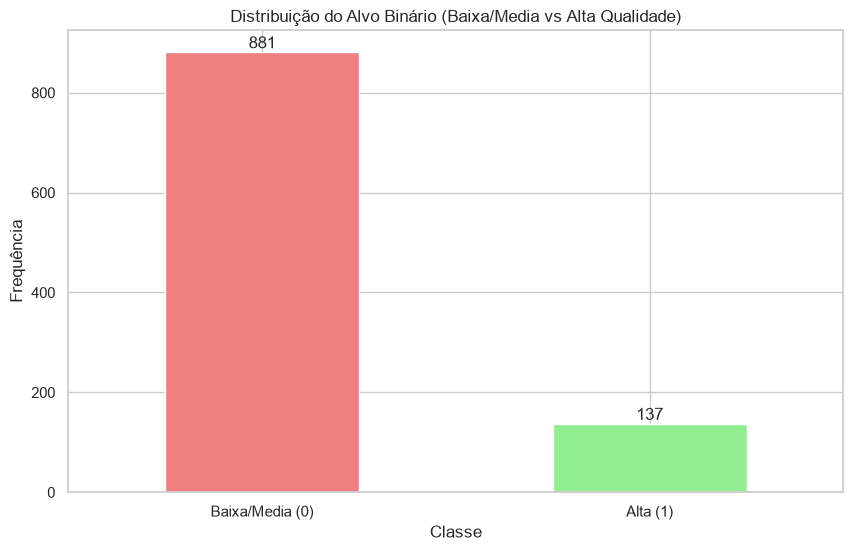

In [33]:
ax = dist_alvo.plot(kind="bar", color=["lightcoral", "lightgreen"])

for patch in ax.patches:
    altura = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.text(x, altura + 1, f"{int(altura)}", ha="center", va="bottom")

plt.title("Distribuição do Alvo Binário (Baixa/Media vs Alta Qualidade)")
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.show()

### Separacao treino/teste (estratificada)

`stratify=y` para preservar a proporcao de classes em ambos os conjuntos e `random_state=42` para reprodutibilidade.

In [34]:
random_state = 42

In [35]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=random_state, stratify=y
)
print(f"Treino: {X_train.shape[0]} amostras ({y_train.mean():.1%} alta qualidade, {(1 - y_train.mean()):.1%} Média/Baixa qualidade)")
print(f"Teste:  {X_test.shape[0]} amostras ({y_test.mean():.1%} alta qualidade), {(1 - y_test.mean()):.1%} Média/Baixa qualidade)")

Treino: 814 amostras (13.5% alta qualidade, 86.5% Média/Baixa qualidade)
Teste:  204 amostras (13.2% alta qualidade), 86.8% Média/Baixa qualidade)


Amostra do X_train:

In [36]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
814,7.0000,0.4200,0.1900,2.3000,0.0710,18.0000,36.0000,0.9948,3.3900,0.5600,10.9000
628,9.1000,0.2900,0.3300,2.0500,0.0630,13.0000,27.0000,0.9952,3.2600,0.8400,11.7000
883,7.6000,0.3000,0.4200,2.0000,0.0520,6.0000,24.0000,0.9963,3.4400,0.8200,11.9000
547,11.7000,0.2800,0.4700,1.7000,0.0540,17.0000,32.0000,0.9969,3.1500,0.6700,10.6000
138,7.0000,0.4900,0.4900,5.6000,0.0600,26.0000,121.0000,0.9974,3.3400,0.7600,10.5000
...,...,...,...,...,...,...,...,...,...,...,...
953,7.5000,0.3800,0.5700,2.3000,0.1060,5.0000,12.0000,0.9960,3.3600,0.5500,11.4000
522,7.6000,0.4800,0.3100,2.8000,0.0700,4.0000,15.0000,0.9969,3.2200,0.5500,10.3000
575,9.1000,0.2800,0.4600,9.0000,0.1140,3.0000,9.0000,0.9990,3.1800,0.6000,10.9000
355,9.4000,0.4300,0.2400,2.8000,0.0920,14.0000,45.0000,0.9980,3.1900,0.7300,10.0000


Amostra do X_test:

In [37]:
X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
284,9.3000,0.4800,0.2900,2.1000,0.1270,6.0000,16.0000,0.9968,3.2200,0.7200,11.2000
644,7.9000,0.3100,0.3200,1.9000,0.0660,14.0000,36.0000,0.9936,3.4100,0.5600,12.6000
864,8.7000,0.7800,0.5100,1.7000,0.4150,12.0000,66.0000,0.9962,3.0000,1.1700,9.2000
564,10.1000,0.4500,0.2300,1.9000,0.0820,10.0000,18.0000,0.9977,3.2200,0.6500,9.3000
551,7.2000,0.6350,0.0700,2.6000,0.0770,16.0000,86.0000,0.9975,3.5100,0.5400,9.7000
...,...,...,...,...,...,...,...,...,...,...,...
653,6.4000,0.3900,0.3300,3.3000,0.0460,12.0000,53.0000,0.9929,3.3600,0.6200,12.2000
558,8.8000,0.6100,0.1900,4.0000,0.0940,30.0000,69.0000,0.9979,3.2200,0.5000,10.0000
38,10.2000,0.4200,0.5700,3.4000,0.0700,4.0000,10.0000,0.9971,3.0400,0.6300,9.6000
792,7.5000,0.5900,0.2200,1.8000,0.0820,43.0000,60.0000,0.9950,3.1000,0.4200,9.2000


---
## DESENVOLVIMENTO DOS MODELOS

Cada modelo é montado dentro de um `Pipeline` do scikit-learn com
`StandardScaler`, garantindo que a padronizacao seja ajustada apenas no treino de cada fold (sem vazamento). Tratamento do desbalanceamento com `class_weight="balanced"`. Otiização os hiperparametros com `GridSearchCV` + `StratifiedKFold(5)`, usando **ROC-AUC** como métrica de seleção (que é mais robusta à classes desbalanceadas).

Seguem os Modelos comparados:

1. **Baseline** (classe majoritária) — referência mínima.
2. **Regressao Logística** — modelo linear interpretável.
3. **SVM** — margens de decisão não lineares.
4. **Random Forest** — Árvores.
5. **Gradient Boosting** — Sequencial.


In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

model_space = {
    "LogisticRegression": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",random_state=random_state))]),
        {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    ),
    "SVM_RBF": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", CalibratedClassifierCV(
                      estimator=SVC(kernel="rbf", class_weight="balanced", random_state=random_state),
                      method="sigmoid",
                      cv=3,
                      ensemble=False
                  ))]),
        {"clf__estimator__C": [0.5, 1.0, 10.0], "clf__estimator__gamma": ["scale", 0.1]},
    ),
    "RandomForest": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", RandomForestClassifier(class_weight="balanced",random_state=random_state))]),
        {"clf__n_estimators": [300, 500], "clf__max_depth": [None, 8, 15],
         "clf__min_samples_leaf": [1, 2]},
    ),
    "GradientBoosting": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", GradientBoostingClassifier(random_state=random_state))]),
        {"clf__n_estimators": [200, 400], "clf__learning_rate": [0.05, 0.1],
         "clf__max_depth": [2, 3]},
    ),
}

fitted = {}
for name, (pipe, grid) in model_space.items():
    search = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    print(f"{name:20s} CV ROC-AUC = {search.best_score_:.4f} | {search.best_params_}")

LogisticRegression   CV ROC-AUC = 0.8803 | {'clf__C': 0.01}
SVM_RBF              CV ROC-AUC = 0.8724 | {'clf__estimator__C': 0.5, 'clf__estimator__gamma': 'scale'}
RandomForest         CV ROC-AUC = 0.8741 | {'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 500}
GradientBoosting     CV ROC-AUC = 0.8674 | {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200}


---
## AVALIACAO DOS MODELOS NO CONJUNTO DE TESTE

Detalhe do accuracy, precision, recall, F1 e ROC-AUC. 

Como as classes são desbalanceadas, priorizei recall da classe Alta e ROC-AUC em vez de apenas a acurácia.

In [39]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

rows, preds, scores = [], {}, {}
# Baseline
yp = baseline.predict(X_test)
rows.append({"modelo": "Baseline (majoritaria)",
             "accuracy": accuracy_score(y_test, yp), "precision": 0.0,
             "recall": 0.0, "f1": 0.0, "roc_auc": np.nan})
for name, model in fitted.items():
    yp = model.predict(X_test)
    ys = model.predict_proba(X_test)[:, 1]
    preds[name], scores[name] = yp, ys
    rows.append({"modelo": name,
                 "accuracy": accuracy_score(y_test, yp),
                 "precision": precision_score(y_test, yp, zero_division=0),
                 "recall": recall_score(y_test, yp, zero_division=0),
                 "f1": f1_score(y_test, yp, zero_division=0),
                 "roc_auc": roc_auc_score(y_test, ys)})

results_df = pd.DataFrame(rows).set_index("modelo").sort_values("roc_auc", ascending=False)
best_name = results_df.drop(index="Baseline (majoritaria)")["roc_auc"].idxmax()
print(f"Melhor modelo por ROC-AUC: {best_name}\n")
results_df.round(4)

Melhor modelo por ROC-AUC: RandomForest



,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
RandomForest,0.8725,0.5152,0.6296,0.5667,0.9190
SVM_RBF,0.9069,0.7500,0.4444,0.5581,0.9037
GradientBoosting,0.8922,0.6316,0.4444,0.5217,0.8931
LogisticRegression,0.7941,0.3684,0.7778,0.5000,0.8922
Baseline (majoritaria),0.8676,0.0000,0.0000,0.0000,NaN


#### Comparacao visual dos modelos (ROC-AUC)

C:\Users\bruno.oliveira\AppData\Local\Temp\ipykernel_24368\379210963.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y="modelo", x="roc_auc", palette="viridis", ax=ax)


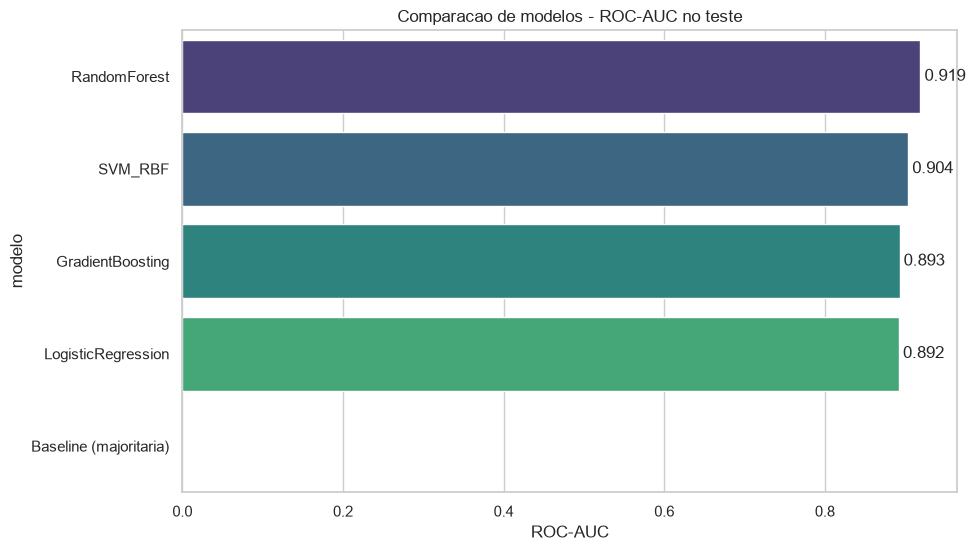

In [40]:
fig, ax = plt.subplots()
plot_df = results_df.reset_index()
sns.barplot(data=plot_df, y="modelo", x="roc_auc", palette="viridis", ax=ax)
ax.set_title("Comparacao de modelos - ROC-AUC no teste")
ax.set_xlabel("ROC-AUC")
for i, v in enumerate(plot_df["roc_auc"].values):
    if not np.isnan(v):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.show()

#### Matriz de confusao e classification report do melhor modelo

                 precision    recall  f1-score   support

Baixa/Media (0)     0.9415    0.9096    0.9253       177
       Alta (1)     0.5152    0.6296    0.5667        27

       accuracy                         0.8725       204
      macro avg     0.7283    0.7696    0.7460       204
   weighted avg     0.8851    0.8725    0.8778       204



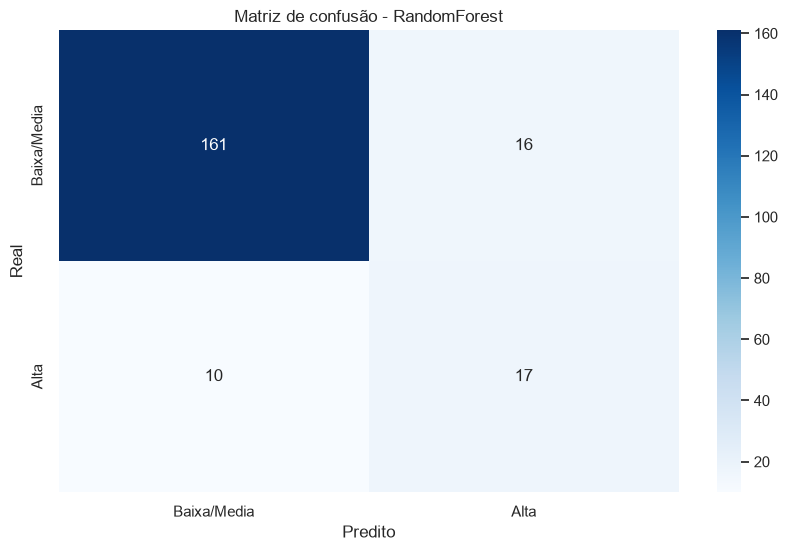

In [41]:
print(classification_report(y_test, preds[best_name],
      target_names=["Baixa/Media (0)", "Alta (1)"], digits=4))

cm = confusion_matrix(y_test, preds[best_name])
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Baixa/Media", "Alta"],
            yticklabels=["Baixa/Media", "Alta"], ax=ax)
ax.set_title(f"Matriz de confusão - {best_name}")
ax.set_xlabel("Predito"); ax.set_ylabel("Real")
plt.show()

#### Curvas ROC

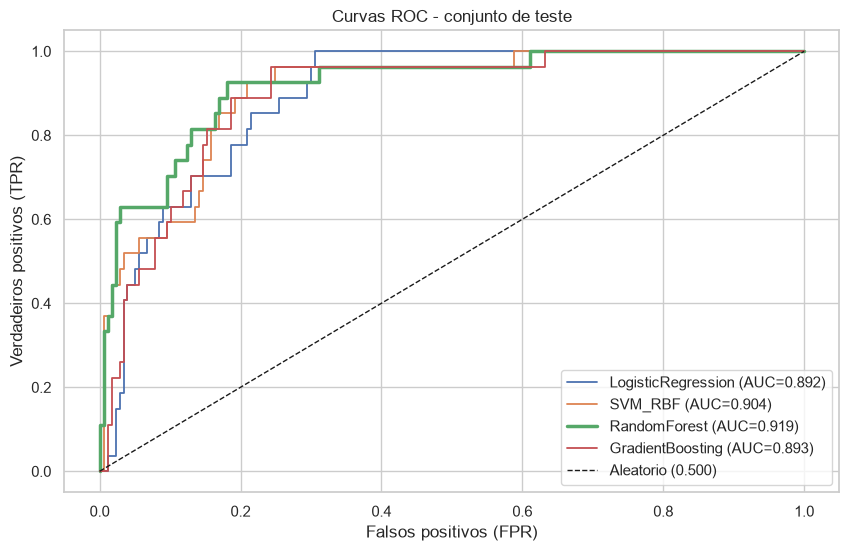

In [42]:
fig, ax = plt.subplots()
for name, ys in scores.items():
    fpr, tpr, _ = roc_curve(y_test, ys)
    auc = roc_auc_score(y_test, ys)
    lw = 2.5 if name == best_name else 1.3
    ax.plot(fpr, tpr, lw=lw, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio (0.500)")
ax.set_xlabel("Falsos positivos (FPR)"); ax.set_ylabel("Verdadeiros positivos (TPR)")
ax.set_title("Curvas ROC - conjunto de teste"); ax.legend(loc="lower right")
plt.show()

---

## Interpretando os Resultados

Quais variaveis físico-químicas mais influenciam a qualidade do vinho?

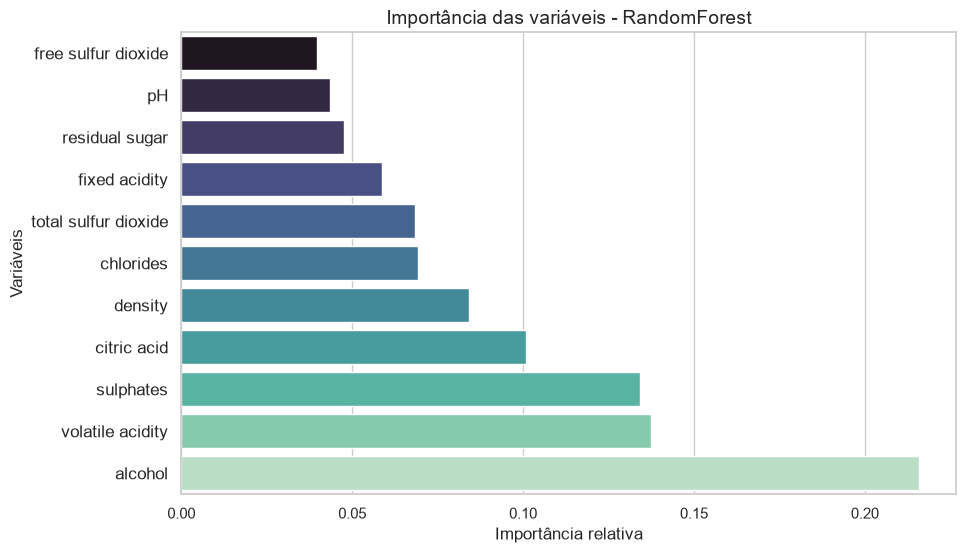

alcohol                0.2160
volatile acidity       0.1374
sulphates              0.1341
citric acid            0.1007
density                0.0841
chlorides              0.0694
total sulfur dioxide   0.0684
fixed acidity          0.0588
residual sugar         0.0477
pH                     0.0435
free sulfur dioxide    0.0398
dtype: float64

In [43]:
clf = fitted[best_name].named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=feature_names)
    titulo = f"Importância das variáveis - {best_name}"
else:
    imp = pd.Series(np.abs(clf.coef_[0]), index=feature_names)
    titulo = f"|Coeficientes| - {best_name}"
imp = imp.sort_values()

plot_df = imp.reset_index()
plot_df.columns = ["variavel", "importancia"]

fig, ax = plt.subplots()
sns.barplot(
    data=plot_df,
    x="importancia",
    y="variavel",
    hue="variavel",
    palette="mako",
    legend=False,
    ax=ax,
    dodge=False,
    orient="h"
 )
ax.set_title(titulo, fontsize=14)
ax.set_xlabel("Importância relativa")
ax.set_ylabel("Variáveis")
ax.tick_params(axis="y", labelsize=12)
plt.show()
imp.sort_values(ascending=False)

---

## Concluindo

- O problema foi tratado como **classificação binaria** (alta qualidade: `quality >= 7`),com forte **desbalanceamento** (~13% de vinhos de alta qualidade). A variável original quality, que representa a nota atribuída por especialistas, foi transformada em uma variável alvo binária: vinhos com quality >= 7 foram classificados como alta qualidade, enquanto vinhos com quality < 7 foram classificados como baixa ou média qualidade. Assim, os modelos foram treinados para distinguir entre esses dois grupos, com foco especial na identificação correta dos vinhos de alta qualidade.

- Foram comparados baseline + 4 modelos em pipelines com padronização, tuning por validação cruzada e avaliação em teste, sem vazamento de dados.

- O **Random Forest** apresentou o melhor ROC-AUC no teste, superando com folga o baseline (que tem recall zero para a classe de interesse, mostrando por que a **acurácia isolada não bastaria neste caso**).

- As variáveis mais influentes foram **teor alcoolico (alcohol)** **acidez volatil (volatile acidity)** e **sulfatos (sulphates)** — coerentes com o conhecimento enológico: mais álcool e sulfatos e menor acidez volátil tendem a indicar vinhos melhor avaliados.

- **Implicação prática:** o modelo pode atuar como um **triador automático**, sinalizando lotes com maior probabilidade de alta qualidade para priorização, sem substituir a avaliação sensorial do enologo.